In [1]:
import matplotlib.pyplot as plt
import astricaltools as at
import numpy as np
import pandas as pd
import scipy.stats as sc
from astropy import stats
import astropy.units as u
from astropy.io import fits
from astropy.table import vstack, Table
from astropy.time import Time
from astropy.timeseries import TimeSeries
from astropy.coordinates import SkyCoord, EarthLocation, AltAz, Angle

In [47]:
file_numbers = range(1, 10)  # da 001 a 009
base_path = "astri_{:03d}_43_009_00002_R_200101_001_0201_SEB.lv0"  # pattern del nome file

dfs = []  # lista per accumulare i DataFrame
print("\n")
for i in file_numbers:
    filename = base_path.format(i)
    print(f"{filename}")

    with at.io.fits.AstriFits(filename) as hdul:
        data = hdul[1].data

        # Conversione dei campi
        time_ns = data["TIME_NS"].byteswap().newbyteorder().astype(np.int64)
        time_s  = data["TIME_S"].byteswap().newbyteorder().astype(np.int64)
        event   = data["EVTNUM"].byteswap().newbyteorder().astype(np.int64)
        mcrun   = data["MCRUNNUM"].byteswap().newbyteorder().astype(np.int64)
        ntel= data["NTRIGTEL"]
        time_abs = time_s * 10**9 + time_ns  # tempo assoluto in ns
        hg, lg, ttp = hdul.get_data('events', ['hi', 'lo', 'ttp'])
        time_abs = time_s * 10**9 + time_ns  # tempo assoluto in ns
            #creo il dataframe
        df = pd.DataFrame({
                "TIME_NS": time_ns,
                "TIME_S": time_s,
                "TIME_ABS": time_abs,
                "EVENT": event,
                "MCRUN": mcrun,
                "TEL_ID": i,
                "num_tel": ntel,
                "HG": list(hg),             
                "LG": list(lg),
                "TTP": list(ttp),
            })

        dfs.append(df)
df_all = pd.concat(dfs, ignore_index=True)
df_all_sorted= df_all.sort_values(by="TIME_ABS").reset_index(drop=True)
df_all_sorted["shape"] = df_all_sorted["HG"].apply(np.sum).to_numpy()
#df
#print(df_all_sorted.head())
#print(len(df_all_sorted))




astri_001_43_009_00002_R_200101_001_0201_SEB.lv0


astri_002_43_009_00002_R_200101_001_0201_SEB.lv0
astri_003_43_009_00002_R_200101_001_0201_SEB.lv0
astri_004_43_009_00002_R_200101_001_0201_SEB.lv0
astri_005_43_009_00002_R_200101_001_0201_SEB.lv0
astri_006_43_009_00002_R_200101_001_0201_SEB.lv0
astri_007_43_009_00002_R_200101_001_0201_SEB.lv0
astri_008_43_009_00002_R_200101_001_0201_SEB.lv0
astri_009_43_009_00002_R_200101_001_0201_SEB.lv0


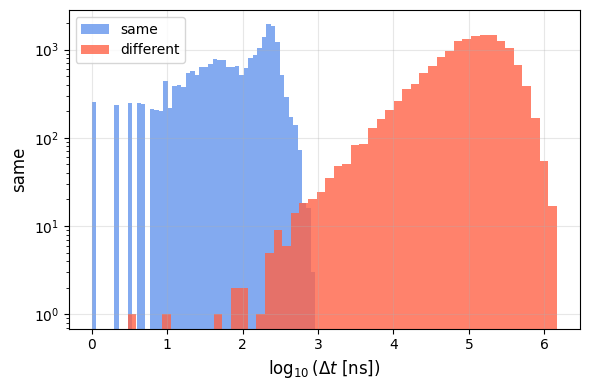

In [48]:
delta_t=np.diff(df_all_sorted["TIME_ABS"])
delta_ts = delta_t[delta_t > 0] #uso maschere e cambio
#df_all_sorted=df_all_sorted[df_all_sorted["shape"]>5.16e6]
#df_all_sorted=df_all_sorted[df_all_sorted["num_tel"]>=3]
#ordino eventi con il for e suddivisione same e different
df_all_sorted=df_all_sorted.sort_values(["MCRUN","EVENT","TIME_ABS"]).reset_index(drop=True)
delta_t_same = []
delta_t_diff = []

for i in range(1, len(df_all_sorted)):
    if ((df_all_sorted.loc[i, "MCRUN"]==df_all_sorted.loc[i-1, "MCRUN"])&
        (df_all_sorted.loc[i, "EVENT"] ==df_all_sorted.loc[i-1, "EVENT"])):
        delta_t_same.append(df_all_sorted.loc[i, "TIME_ABS"]-
                            df_all_sorted.loc[i-1, "TIME_ABS"])
    else:
        delta_t_diff.append(df_all_sorted.loc[i, "TIME_ABS"]-
                            df_all_sorted.loc[i-1, "TIME_ABS"])
delta_t_same = np.array(delta_t_same)
delta_t_diff = np.array(delta_t_diff)
delta_t_same_safe = np.where(delta_t_same > 0, delta_t_same, 1)
delta_t_diff_safe = np.where(delta_t_diff > 0, delta_t_diff, 1)
#suddivido tra stesso evento e evento separato sostituendo i deltat con 1
plt.figure(figsize=(6, 4))
plt.hist(np.log10(delta_t_same[delta_t_same > 0]), bins=50, color='cornflowerblue',
         alpha=0.8,label='same')
plt.hist(np.log10(delta_t_diff[delta_t_diff > 0]),bins=50, color='tomato',
         alpha=0.8,label='different')
plt.yscale('log')
plt.xlabel(r'$\log_{10}(\Delta t\ \mathrm{[ns]})$', fontsize=12)
plt.ylabel('same', fontsize=12)
#plt.xlim(left=0)
plt.tight_layout()
plt.grid(alpha=0.3)
plt.legend()
plt.show()


In [49]:

threshold_ns = 1000  # equivalente a log10(delta_t) < 3

#delta_t entro la soglia
delta_t_same_window = delta_t_same[(delta_t_same > 0) & (delta_t_same < threshold_ns)]
delta_t_diff_window = delta_t_diff[(delta_t_diff > 0) & (delta_t_diff < threshold_ns)]

n_same_in_window = len(delta_t_same_window)
n_diff_in_window = len(delta_t_diff_window)
total_in_window = n_same_in_window + n_diff_in_window

print(f"Eventi nella finestra temporale (Δt < {threshold_ns} ns):")
print(f"  - Stesso evento (same): {n_same_in_window} ({n_same_in_window/total_in_window*100:.1f}%)")
print(f"  - Eventi diversi (different): {n_diff_in_window} ({n_diff_in_window/total_in_window*100:.1f}%)")
print(f"  - Totale: {total_in_window}")

# Se vuoi salvare gli indici degli eventi originali nella finestra temporale
indices_same_window = []
indices_diff_window = []

for i in range(1, len(df_all_sorted)):
    dt = df_all_sorted.loc[i, "TIME_ABS"] - df_all_sorted.loc[i-1, "TIME_ABS"]
    
    if 0 < dt < threshold_ns:
        if ((df_all_sorted.loc[i, "MCRUN"] == df_all_sorted.loc[i-1, "MCRUN"]) &
            (df_all_sorted.loc[i, "EVENT"] == df_all_sorted.loc[i-1, "EVENT"])):
            indices_same_window.append(i)
        else:
            indices_diff_window.append(i)

# Crea dataframe con solo gli eventi nella finestra
df_same_window = df_all_sorted.loc[indices_same_window].copy()
df_diff_window = df_all_sorted.loc[indices_diff_window].copy()

print(f"\nRighe del dataframe nella finestra:")
print(f"  - Same events: {len(df_same_window)}")
print(f"  - Different events: {len(df_diff_window)}")


Eventi nella finestra temporale (Δt < 1000 ns):
  - Stesso evento (same): 22913 (99.6%)
  - Eventi diversi (different): 82 (0.4%)
  - Totale: 22995



Righe del dataframe nella finestra:
  - Same events: 22913
  - Different events: 82


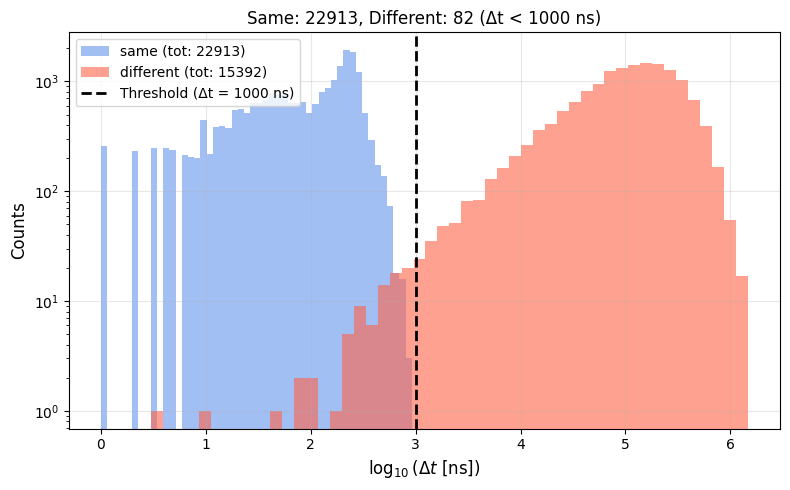

In [50]:

plt.figure(figsize=(8, 5))
plt.hist(np.log10(delta_t_same[delta_t_same > 0]), bins=50, color='cornflowerblue',
         alpha=0.6, label=f'same (tot: {len(delta_t_same[delta_t_same > 0])})')
plt.hist(np.log10(delta_t_diff[delta_t_diff > 0]), bins=50, color='tomato',
         alpha=0.6, label=f'different (tot: {len(delta_t_diff[delta_t_diff > 0])})')

# Linea verticale alla soglia
plt.axvline(x=3, color='black', linestyle='--', linewidth=2, 
            label=f'Threshold (Δt = {threshold_ns} ns)')

plt.yscale('log')
plt.xlabel(r'$\log_{10}(\Delta t\ \mathrm{[ns]})$', fontsize=12)
plt.ylabel('Counts', fontsize=12)
plt.title(f'Same: {n_same_in_window}, Different: {n_diff_in_window} (Δt < {threshold_ns} ns)')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Eventi unici in df_diff_window: 82
Righe totali in df_sel (tutti i telescopi): 237
Telescopi per evento in media: 2.9


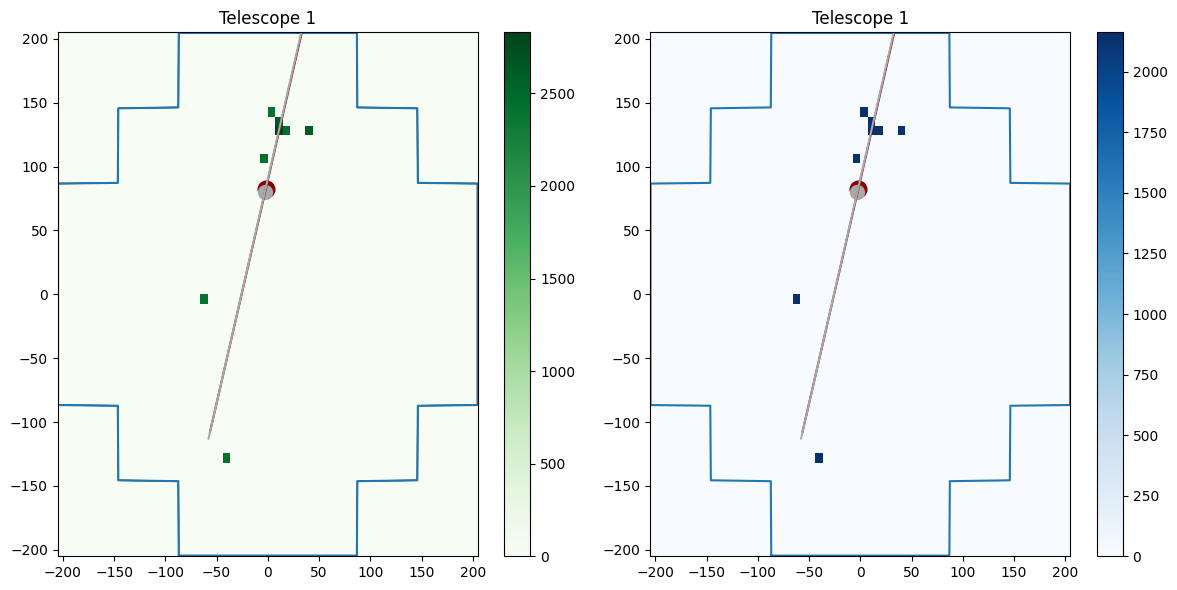

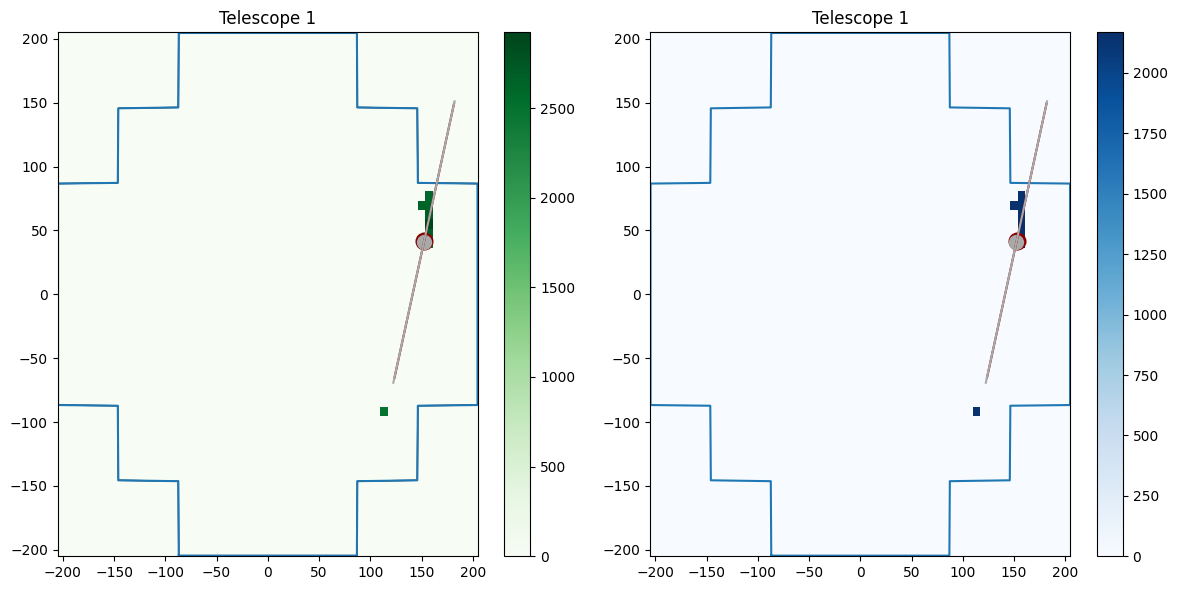

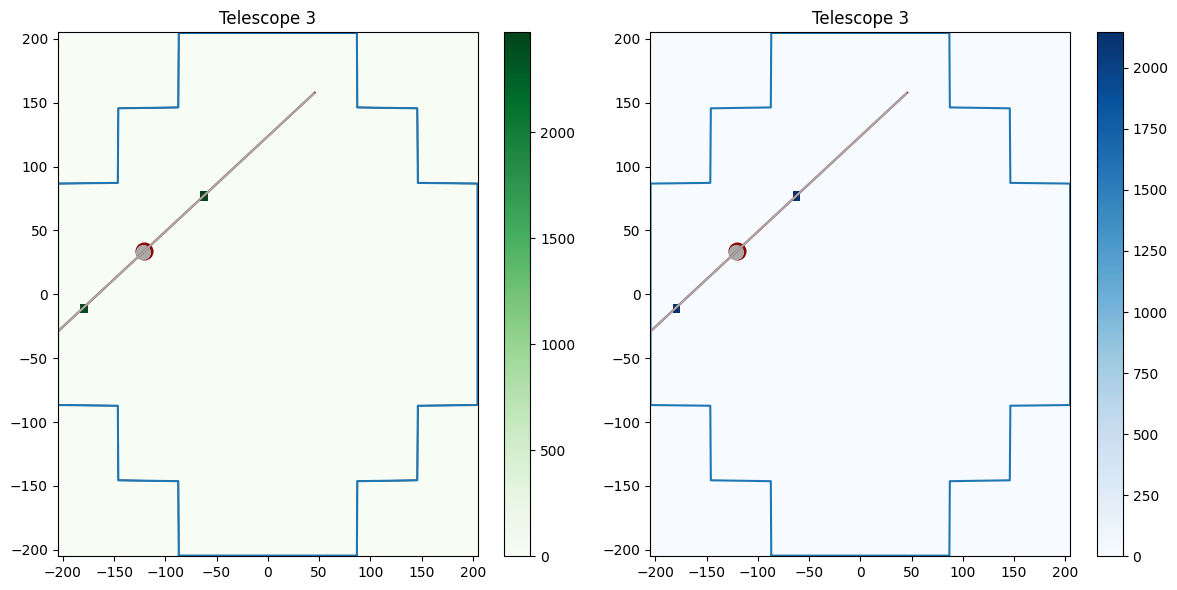

ZeroDivisionError: Weights sum to zero, can't be normalized

In [51]:
# Estrai le coppie (MCRUN, EVENT) uniche da df_diff_window
eventi_selezionati = df_diff_window[["MCRUN", "EVENT"]].drop_duplicates()

# Filtra df_all_sorted per tenere SOLO questi eventi (con tutti i loro telescopi)
df_sel = df_all_sorted.merge(
    eventi_selezionati, 
    on=["MCRUN", "EVENT"], 
    how="inner"
)

print(f"Eventi unici in df_diff_window: {len(eventi_selezionati)}")
print(f"Righe totali in df_sel (tutti i telescopi): {len(df_sel)}")
print(f"Telescopi per evento in media: {len(df_sel)/len(eventi_selezionati):.1f}")
#lo stereo trigger lo avrebbe riconosciuto che sono due eventi diversi
xfp, yfp = at.utils.camera.get_xy_footprint()
y_pix, x_pix = at.utils.camera.get_pixels_position_matrix().T

x_pix = at.reshape(x_pix)
y_pix = at.reshape(y_pix)

rette_hg = []
rette_lg = []

# ============================================================
#   calcolo, sigma clip, istogrammi, salvataggio rette

for iv in range(5):

    itel = df_sel["TEL_ID"].iloc[iv]
    hgev = np.array(df_sel['HG'])[iv]
    lgev = np.array(df_sel['LG'])[iv]
    ttpev = np.array(df_sel['TTP'])[iv]

    # mask di pixel buoni
    pxmask = (hgev > 2400) & (ttpev < 255)

    # --------------------------
    # SIGMA-CLIPPING
    
    xx = x_pix[pxmask].flatten()
    yy = y_pix[pxmask].flatten()
    w_hg = hgev[pxmask].flatten()
    w_lg = lgev[pxmask].flatten()

    mx0 = np.average(xx, weights=w_hg)
    my0 = np.average(yy, weights=w_hg)

    r = np.sqrt((xx - mx0)**2 + (yy - my0)**2)

    r_clip, low, high = sc.sigmaclip(r, low=3.0, high=3.0)
    keep = (r >= low) & (r <= high)

    xx_sc = xx[keep]
    yy_sc = yy[keep]
    w_hg_sc = w_hg[keep]
    w_lg_sc = w_lg[keep]
    # --------------------------

    # ---------- centroidi ----------
    meanx_hg = np.average(xx_sc, weights=w_hg_sc)
    meany_hg = np.average(yy_sc, weights=w_hg_sc)

    meanx_lg = np.average(xx_sc, weights=w_lg_sc)
    meany_lg = np.average(yy_sc, weights=w_lg_sc)

    # ---------- covarianze ----------
    cov_hg = np.cov([xx_sc, yy_sc], aweights=w_hg_sc)
    cov_lg = np.cov([xx_sc, yy_sc], aweights=w_lg_sc)

    # ---------- direzione ellisse ----------
    l1_hg = (cov_hg[0,0] + cov_hg[1,1])/2 + np.sqrt(((cov_hg[0,0]-cov_hg[1,1])/2)**2 + cov_hg[0,1]**2)
    l1_lg = (cov_lg[0,0] + cov_lg[1,1])/2 + np.sqrt(((cov_lg[0,0]-cov_lg[1,1])/2)**2 + cov_lg[0,1]**2)

    theta_hg = np.arctan2(l1_hg - cov_hg[0,0], cov_hg[0,1])
    theta_lg = np.arctan2(l1_lg - cov_lg[0,0], cov_lg[0,1])

    # ---------- salvo le rette ----------
    rette_hg.append({
        "p0": np.array([meanx_hg, meany_hg]),
        "d":  np.array([np.cos(theta_hg), np.sin(theta_hg)]),
        "tel": itel
    })

    rette_lg.append({
        "p0": np.array([meanx_lg, meany_lg]),
        "d":  np.array([np.cos(theta_lg), np.sin(theta_lg)]),
        "tel": itel
    })



    fig, ax = plt.subplots(1, 2, figsize=(12, 6), tight_layout=True)
    ax[0].plot(xfp, yfp, 'k-', linewidth=1)
    hl = ax[0].hist2d(xx, yy, weights=w_hg,
                      range=((-205, 205), (-205, 205)),
                      bins=7*8, cmap='Greens')

    hh = ax[1].hist2d(xx, yy, weights=w_lg,
                      range=((-205, 205), (-205, 205)),
                      bins=7*8, cmap='Blues')

    fig.colorbar(hl[3], ax=ax[0])
    fig.colorbar(hh[3], ax=ax[1])

    for ai in ax:
        ai.plot(xfp, yfp)
        ai.set_title(f"Telescope {itel}")
        ai.plot(meanx_hg, meany_hg, 'o', markersize=12, color='darkred')
        ai.plot(meanx_lg, meany_lg, 'o', markersize=10, color='darkgrey')

        # rette
        ai.plot([meanx_hg - 2*np.sqrt(l1_hg)*np.cos(theta_hg),
                 meanx_hg + 2*np.sqrt(l1_hg)*np.cos(theta_hg)],
                [meany_hg - 2*np.sqrt(l1_hg)*np.sin(theta_hg),
                 meany_hg + 2*np.sqrt(l1_hg)*np.sin(theta_hg)],
                '-', color='darkred')

        ai.plot([meanx_lg - 2*np.sqrt(l1_lg)*np.cos(theta_lg),
                 meanx_lg + 2*np.sqrt(l1_lg)*np.cos(theta_lg)],
                [meany_lg - 2*np.sqrt(l1_lg)*np.sin(theta_lg),
                 meany_lg + 2*np.sqrt(l1_lg)*np.sin(theta_lg)],
                '-', color='darkgrey')

    plt.show()

# ============================================================
#   tutte le rette insieme

fig, ax = plt.subplots(figsize=(6, 6))
# footprint camera 
ax.plot(xfp, yfp, 'k-', linewidth=1)

# calcolo lunghezza estetica delle rette
xmin, xmax = np.min(xfp), np.max(xfp)
ymin, ymax = np.min(yfp), np.max(yfp)
diag = np.sqrt((xmax - xmin)**2 + (ymax - ymin)**2)
L = 0.40 * diag

# centroidi e rette HG
for r in rette_hg:
    p0 = r["p0"]
    d  = r["d"]

    # centroide HG (punto rosso grande)
    ax.scatter(p0[0], p0[1], s=80, color="firebrick", zorder=5)

    # retta lunga HG (firebrick)
    x1 = p0[0] - L * d[0]
    y1 = p0[1] - L * d[1]
    x2 = p0[0] + L * d[0]
    y2 = p0[1] + L * d[1]
    ax.plot([x1, x2], [y1, y2], color="firebrick", linewidth=2, alpha=0.8)

#  centroidi e rette LG 
for r in rette_lg:
    p0 = r["p0"]
    d  = r["d"]

    # centroide LG (punto grigio più piccolo con bordo nero)
    ax.scatter(p0[0], p0[1], s=60, color="grey", edgecolor="black", zorder=5)

    # retta lunga LG (grey)
    x1 = p0[0] - L * d[0]
    y1 = p0[1] - L * d[1]
    x2 = p0[0] + L * d[0]
    y2 = p0[1] + L * d[1]
    ax.plot([x1, x2], [y1, y2], color="grey", linewidth=2, alpha=0.8)

ax.set_title("Tutte le rette (HG firebrick, LG grey)")
ax.set_xlim(-250,250 )
ax.set_ylim(-250,250)

plt.tight_layout()
plt.show()

print("HG rette:", len(rette_hg))
print("LG rette:", len(rette_lg))
print(rette_hg[0])
print(df_sel.columns)

Eventi unici in df_diff_window: 82
Righe totali in df_sel (tutti i telescopi): 237
Telescopi per evento in media: 2.9


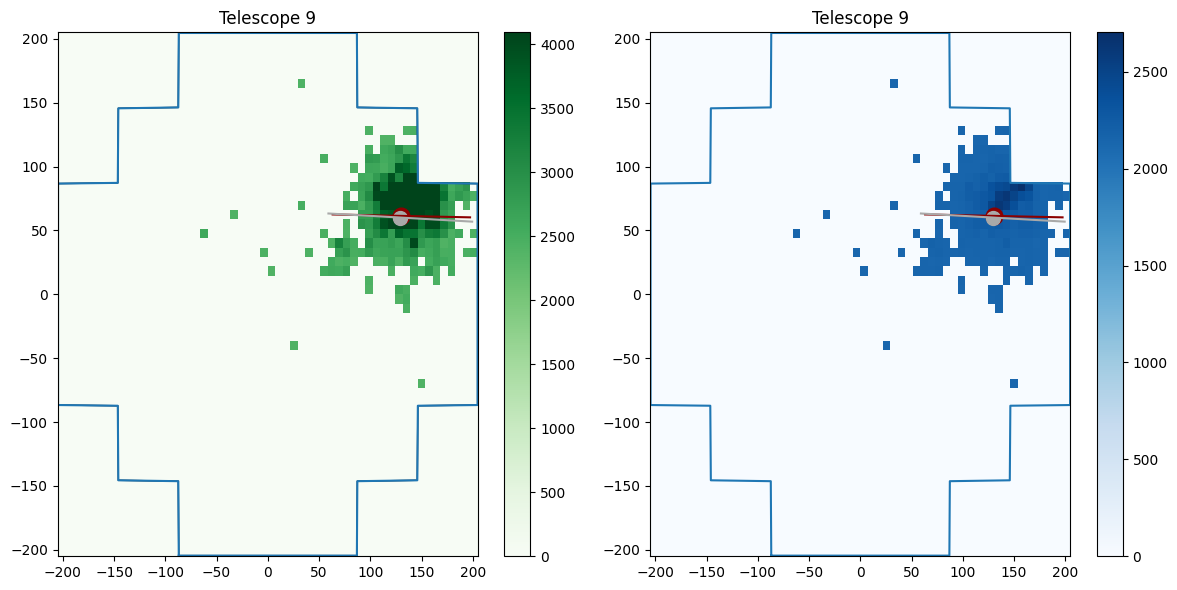

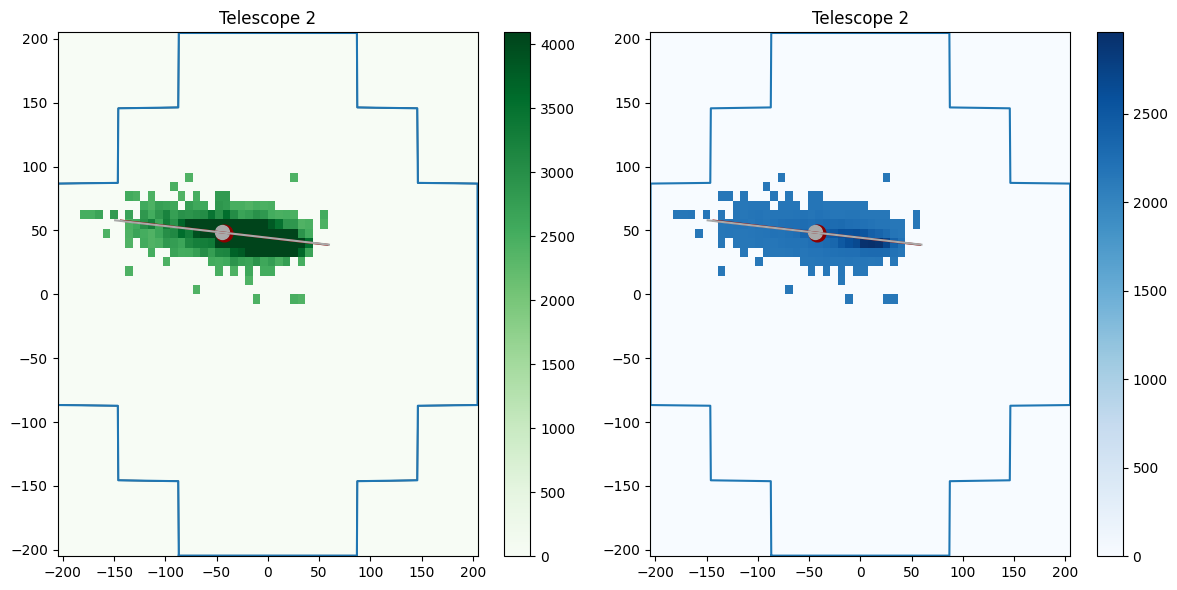

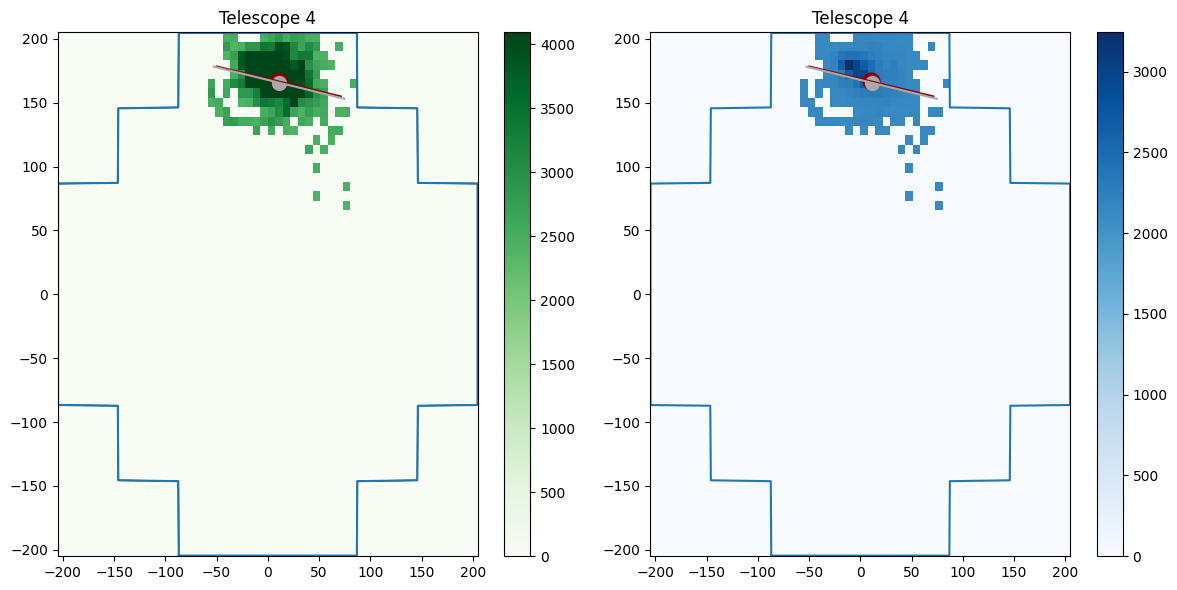

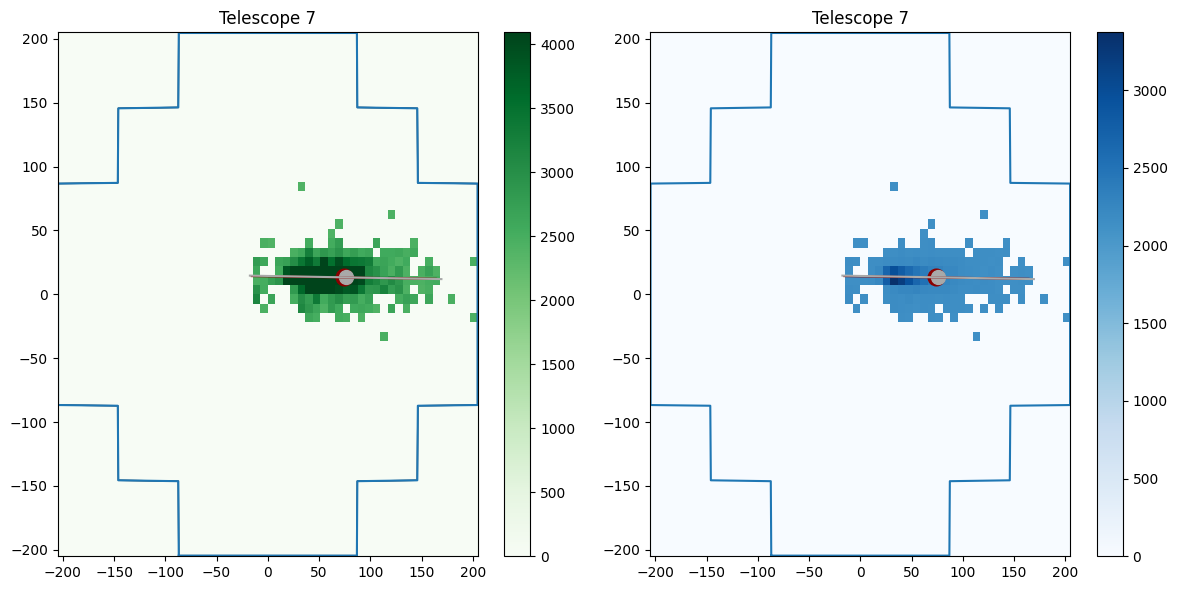

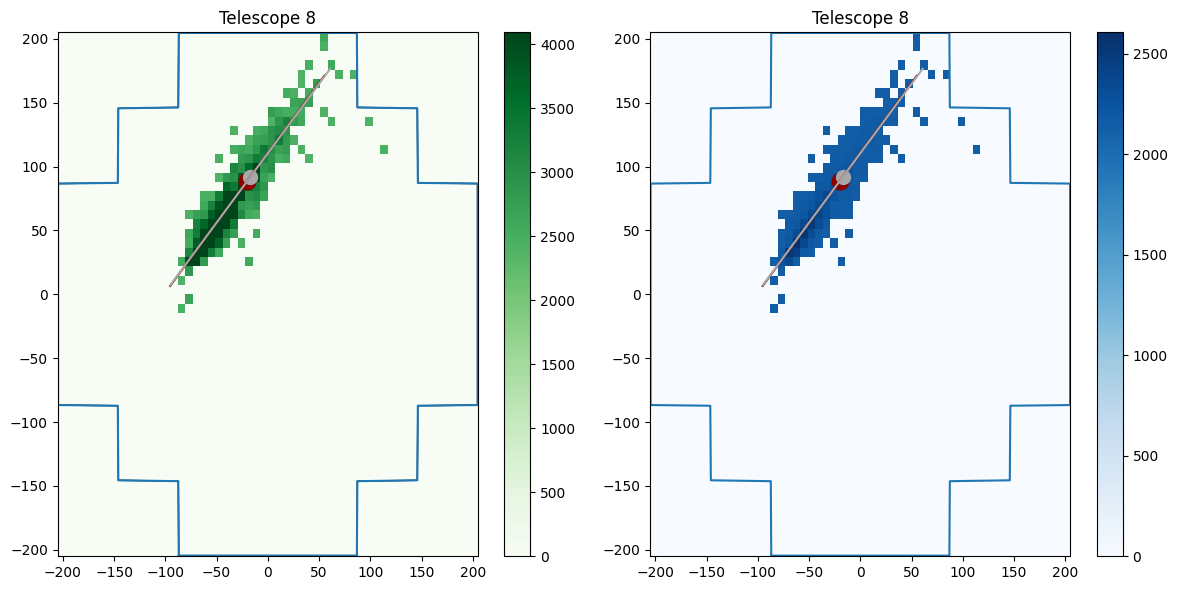

In [52]:
# Estrai le coppie (MCRUN, EVENT) uniche da df_diff_window
eventi_selezionati = df_diff_window[["MCRUN", "EVENT"]].drop_duplicates()

# Filtra df_all_sorted per tenere SOLO questi eventi (con tutti i loro telescopi)
df_sel = df_all_sorted.merge(
    eventi_selezionati, 
    on=["MCRUN", "EVENT"], 
    how="inner"
)

print(f"Eventi unici in df_diff_window: {len(eventi_selezionati)}")
print(f"Righe totali in df_sel (tutti i telescopi): {len(df_sel)}")
print(f"Telescopi per evento in media: {len(df_sel)/len(eventi_selezionati):.1f}")
#lo stereo trigger lo avrebbe riconosciuto che sono due eventi diversi
xfp, yfp = at.utils.camera.get_xy_footprint()
y_pix, x_pix = at.utils.camera.get_pixels_position_matrix().T

x_pix = at.reshape(x_pix)
y_pix = at.reshape(y_pix)

rette_hg = []
rette_lg = []

# ============================================================
#   calcolo, sigma clip, istogrammi, salvataggio rette
df_sel.sort_values(by='shape', ascending=False, inplace=True)
for iv in range(5):

    itel = df_sel["TEL_ID"].iloc[iv]
    hgev = np.array(df_sel['HG'])[iv]
    lgev = np.array(df_sel['LG'])[iv]
    ttpev = np.array(df_sel['TTP'])[iv]

    # mask di pixel buoni
    pxmask = (hgev > 2400) & (ttpev < 255)

    # --------------------------
    # SIGMA-CLIPPING
    
    xx = x_pix[pxmask].flatten()
    yy = y_pix[pxmask].flatten()
    w_hg = hgev[pxmask].flatten()
    w_lg = lgev[pxmask].flatten()

    mx0 = np.average(xx, weights=w_hg)
    my0 = np.average(yy, weights=w_hg)

    r = np.sqrt((xx - mx0)**2 + (yy - my0)**2)

    r_clip, low, high = sc.sigmaclip(r, low=3.0, high=3.0)
    keep = (r >= low) & (r <= high)

    xx_sc = xx[keep]
    yy_sc = yy[keep]
    w_hg_sc = w_hg[keep]
    w_lg_sc = w_lg[keep]
    # --------------------------

    # ---------- centroidi ----------
    meanx_hg = np.average(xx_sc, weights=w_hg_sc)
    meany_hg = np.average(yy_sc, weights=w_hg_sc)

    meanx_lg = np.average(xx_sc, weights=w_lg_sc)
    meany_lg = np.average(yy_sc, weights=w_lg_sc)

    # ---------- covarianze ----------
    cov_hg = np.cov([xx_sc, yy_sc], aweights=w_hg_sc)
    cov_lg = np.cov([xx_sc, yy_sc], aweights=w_lg_sc)

    # ---------- direzione ellisse ----------
    l1_hg = (cov_hg[0,0] + cov_hg[1,1])/2 + np.sqrt(((cov_hg[0,0]-cov_hg[1,1])/2)**2 + cov_hg[0,1]**2)
    l1_lg = (cov_lg[0,0] + cov_lg[1,1])/2 + np.sqrt(((cov_lg[0,0]-cov_lg[1,1])/2)**2 + cov_lg[0,1]**2)

    theta_hg = np.arctan2(l1_hg - cov_hg[0,0], cov_hg[0,1])
    theta_lg = np.arctan2(l1_lg - cov_lg[0,0], cov_lg[0,1])

    # ---------- salvo le rette ----------
    rette_hg.append({
        "p0": np.array([meanx_hg, meany_hg]),
        "d":  np.array([np.cos(theta_hg), np.sin(theta_hg)]),
        "tel": itel
    })

    rette_lg.append({
        "p0": np.array([meanx_lg, meany_lg]),
        "d":  np.array([np.cos(theta_lg), np.sin(theta_lg)]),
        "tel": itel
    })



    fig, ax = plt.subplots(1, 2, figsize=(12, 6), tight_layout=True)
    ax[0].plot(xfp, yfp, 'k-', linewidth=1)
    hl = ax[0].hist2d(xx, yy, weights=w_hg,
                      range=((-205, 205), (-205, 205)),
                      bins=7*8, cmap='Greens')

    hh = ax[1].hist2d(xx, yy, weights=w_lg,
                      range=((-205, 205), (-205, 205)),
                      bins=7*8, cmap='Blues')

    fig.colorbar(hl[3], ax=ax[0])
    fig.colorbar(hh[3], ax=ax[1])

    for ai in ax:
        ai.plot(xfp, yfp)
        ai.set_title(f"Telescope {itel}")
        ai.plot(meanx_hg, meany_hg, 'o', markersize=12, color='darkred')
        ai.plot(meanx_lg, meany_lg, 'o', markersize=10, color='darkgrey')

        # rette
        ai.plot([meanx_hg - 2*np.sqrt(l1_hg)*np.cos(theta_hg),
                 meanx_hg + 2*np.sqrt(l1_hg)*np.cos(theta_hg)],
                [meany_hg - 2*np.sqrt(l1_hg)*np.sin(theta_hg),
                 meany_hg + 2*np.sqrt(l1_hg)*np.sin(theta_hg)],
                '-', color='darkred')

        ai.plot([meanx_lg - 2*np.sqrt(l1_lg)*np.cos(theta_lg),
                 meanx_lg + 2*np.sqrt(l1_lg)*np.cos(theta_lg)],
                [meany_lg - 2*np.sqrt(l1_lg)*np.sin(theta_lg),
                 meany_lg + 2*np.sqrt(l1_lg)*np.sin(theta_lg)],
                '-', color='darkgrey')

    plt.show()



In [53]:
#cerchiamo di riapplicare il SEB


# Parametri
threshold_ns = 1000  # Esempio: 1000 nanosecondi

# 1. Assicurarsi che il DataFrame sia ordinato per TIME_ABS
df_all_sorted = df_all_sorted.sort_values('TIME_ABS').reset_index(drop=True)

# 2. Calcolare le differenze temporali tra eventi consecutivi
df_all_sorted['dt'] = df_all_sorted['TIME_ABS'].diff()

# 3. Creare gruppi temporali basati sulla soglia
# Quando dt > threshold_ns, inizia un nuovo gruppo
df_all_sorted['new_group'] = (df_all_sorted['dt'] > threshold_ns) | (df_all_sorted['dt'].isna())
df_all_sorted['time_group'] = df_all_sorted['new_group'].cumsum()

# 4. Identificare se eventi consecutivi hanno stesso EVENT e MCRUN
df_all_sorted['same_event'] = (df_all_sorted['EVENT'] == df_all_sorted['EVENT'].shift(1))
df_all_sorted['same_mcrun'] = (df_all_sorted['MCRUN'] == df_all_sorted['MCRUN'].shift(1))
df_all_sorted['same_event_mcrun'] = df_all_sorted['same_event'] & df_all_sorted['same_mcrun']

# 5. Classificare gli eventi
# same_window: stessa finestra temporale E stesso EVENT/MCRUN
# diff_window: stessa finestra temporale MA EVENT o MCRUN diverso
df_all_sorted['window_type'] = None

# Eventi consecutivi nella stessa finestra temporale (dt <= threshold_ns)
same_time_window = ~df_all_sorted['new_group']

df_all_sorted.loc[same_time_window & df_all_sorted['same_event_mcrun'], 'window_type'] = 'same_window'
df_all_sorted.loc[same_time_window & ~df_all_sorted['same_event_mcrun'], 'window_type'] = 'diff_window'

# 6. Estrarre gli eventi di tipo diff_window
diff_window_events = df_all_sorted[df_all_sorted['window_type'] == 'diff_window']

# 7. Identificare tutti i time_group che contengono eventi diff_window
affected_time_groups = diff_window_events['time_group'].unique()

# 8. Estrarre tutti gli eventi appartenenti a questi gruppi temporali
df_linked_events = df_all_sorted[df_all_sorted['time_group'].isin(affected_time_groups)].copy()

# 9. Pulizia: rimuovere colonne temporanee se necessario
df_all_sorted = df_all_sorted.drop(columns=['new_group', 'same_event', 'same_mcrun', 'same_event_mcrun'])

# Risultati
print(f"Numero totale di eventi: {len(df_all_sorted)}")
print(f"Numero di finestre temporali: {df_all_sorted['time_group'].nunique()}")
print(f"Eventi in same_window: {(df_all_sorted['window_type'] == 'same_window').sum()}")
print(f"Eventi in diff_window: {(df_all_sorted['window_type'] == 'diff_window').sum()}")
print(f"Numero di finestre temporali con eventi misti: {len(affected_time_groups)}")
print(f"Numero totale di eventi collegati: {len(df_linked_events)}")

Numero totale di eventi: 38476
Numero di finestre temporali: 15311
Eventi in same_window: 23032
Eventi in diff_window: 133
Numero di finestre temporali con eventi misti: 115
Numero totale di eventi collegati: 629


Numero totale di finestre temporali: 15311
Finestre temporali miste: 115

TIME GROUP 1
Numero di righe (telescopi): 1
EVENT unici: [912]
MCRUN unici: [220000]
Finestra mista: False

  Plot 1/1: TEL_ID=4, EVENT=912, MCRUN=220000
    Troppo pochi pixel (1), skip

Rette HG salvate per questo gruppo: 0
Rette LG salvate per questo gruppo: 0

TIME GROUP 2
Numero di righe (telescopi): 9
EVENT unici: [1007]
MCRUN unici: [220000]
Finestra mista: False

  Plot 1/5: TEL_ID=7, EVENT=1007, MCRUN=220000


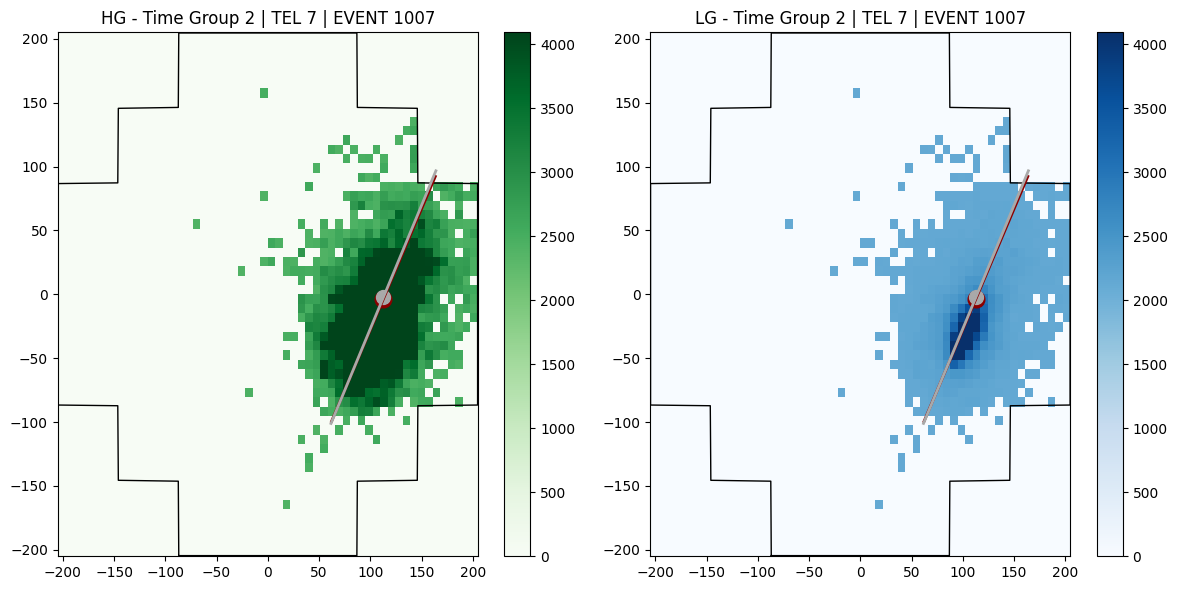

  Plot 2/5: TEL_ID=6, EVENT=1007, MCRUN=220000


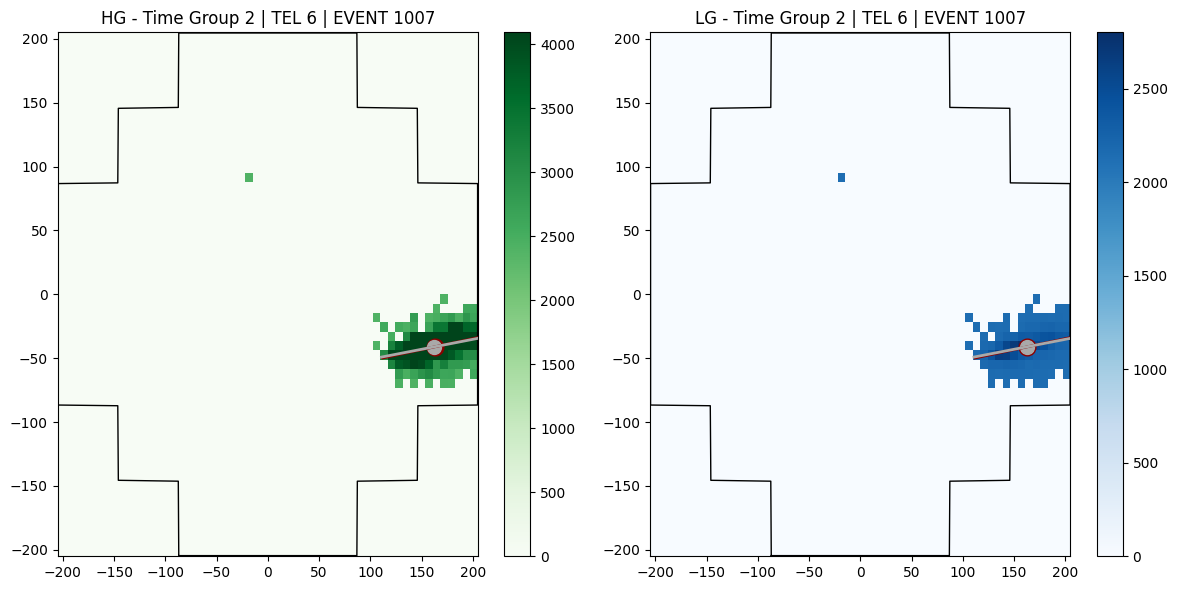

  Plot 3/5: TEL_ID=9, EVENT=1007, MCRUN=220000


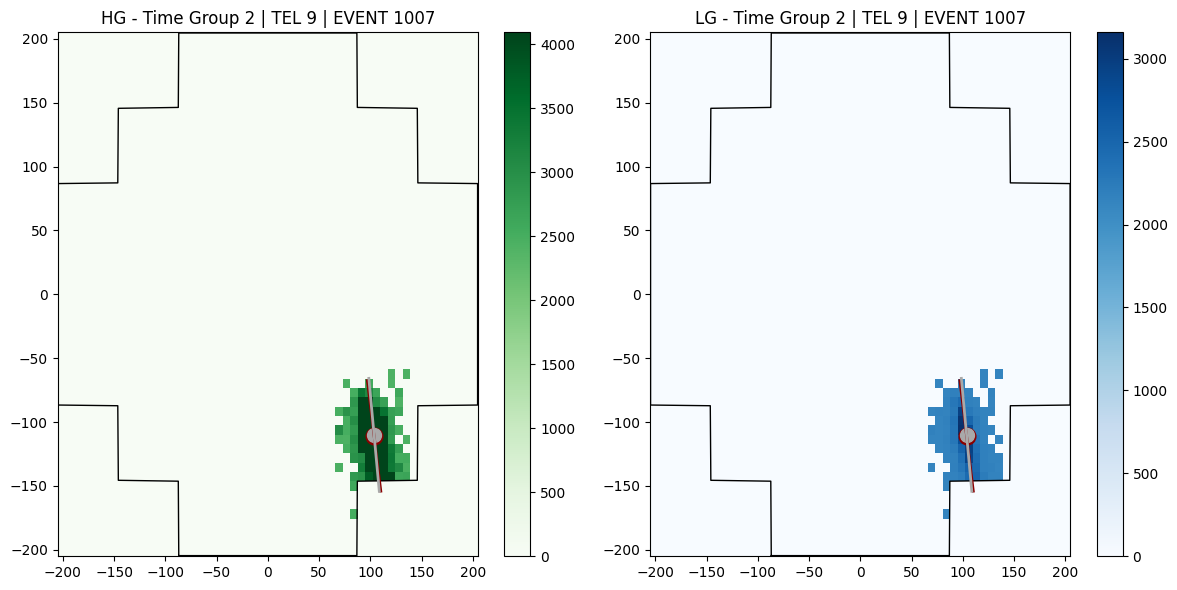

  Plot 4/5: TEL_ID=4, EVENT=1007, MCRUN=220000


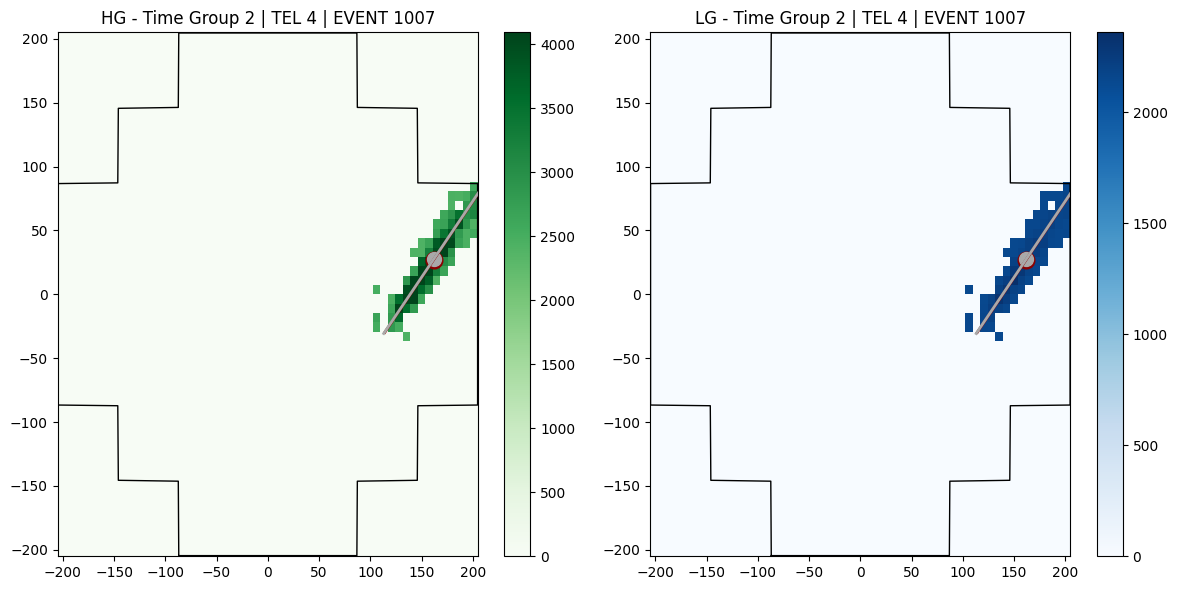

  Plot 5/5: TEL_ID=8, EVENT=1007, MCRUN=220000


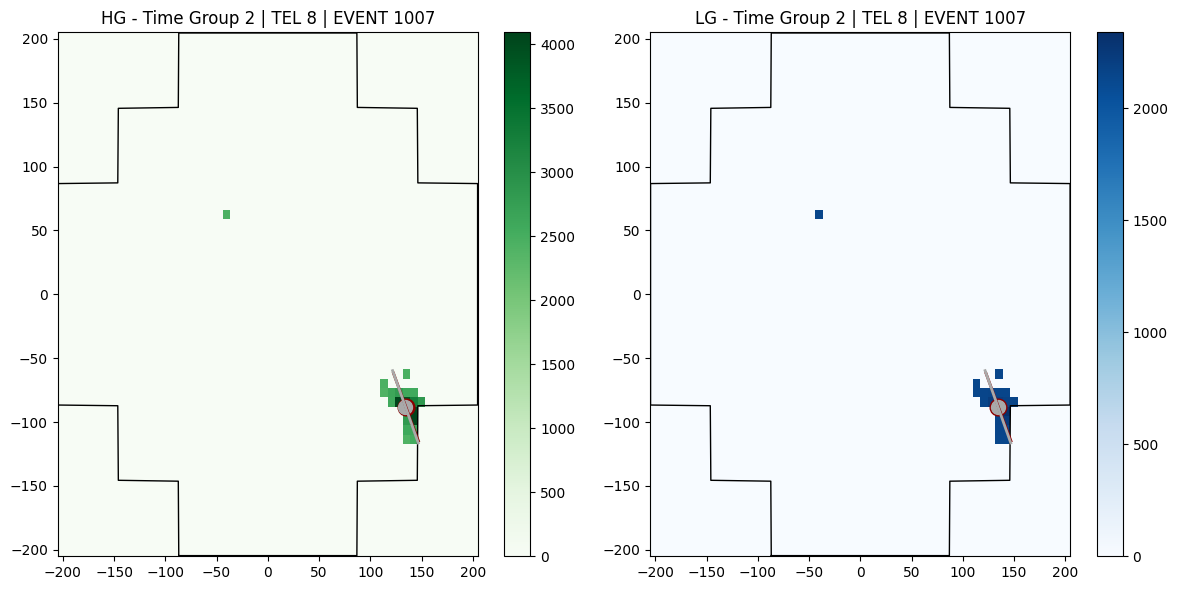


Rette HG salvate per questo gruppo: 5
Rette LG salvate per questo gruppo: 5

TIME GROUP 3
Numero di righe (telescopi): 1
EVENT unici: [1806]
MCRUN unici: [220000]
Finestra mista: False

  Plot 1/1: TEL_ID=4, EVENT=1806, MCRUN=220000
    Troppo pochi pixel (1), skip

Rette HG salvate per questo gruppo: 0
Rette LG salvate per questo gruppo: 0


In [55]:
# Parametri
threshold_ns = 1000  # soglia temporale in nanosecondi

# 1. Assicurarsi che il DataFrame sia ordinato per TIME_ABS
df_all_sorted = df_all_sorted.sort_values('TIME_ABS').reset_index(drop=True)

# 2. Calcolare le differenze temporali e creare gruppi temporali
df_all_sorted['dt'] = df_all_sorted['TIME_ABS'].diff()
df_all_sorted['new_group'] = (df_all_sorted['dt'] > threshold_ns) | (df_all_sorted['dt'].isna())
df_all_sorted['time_group'] = df_all_sorted['new_group'].cumsum()

# 3. Pulizia
df_all_sorted = df_all_sorted.drop(columns=['new_group'])

# Identificare finestre miste (opzionale, se vuoi filtrare)
group_info = df_all_sorted.groupby('time_group').agg({
    'EVENT': 'nunique',
    'MCRUN': 'nunique'
}).reset_index()
group_info['is_mixed'] = (group_info['EVENT'] > 1) | (group_info['MCRUN'] > 1)

print(f"Numero totale di finestre temporali: {df_all_sorted['time_group'].nunique()}")
print(f"Finestre temporali miste: {group_info['is_mixed'].sum()}")

# Setup camera
xfp, yfp = at.utils.camera.get_xy_footprint()
y_pix, x_pix = at.utils.camera.get_pixels_position_matrix().T
x_pix = at.reshape(x_pix)
y_pix = at.reshape(y_pix)

# Iterare sui primi 3 gruppi temporali
time_groups_to_plot = df_all_sorted['time_group'].unique()[:3]

for time_group in time_groups_to_plot:
    
    # Estrai tutti gli eventi di questo gruppo temporale
    df_window = df_all_sorted[df_all_sorted['time_group'] == time_group].copy()
    
    # Informazioni sul gruppo
    n_events_in_window = len(df_window)
    unique_events = df_window['EVENT'].unique()
    unique_mcruns = df_window['MCRUN'].unique()
    is_mixed = (len(unique_events) > 1) or (len(unique_mcruns) > 1)
    
    print(f"\n{'='*70}")
    print(f"TIME GROUP {time_group}")
    print(f"{'='*70}")
    print(f"Numero di righe (telescopi): {n_events_in_window}")
    print(f"EVENT unici: {unique_events}")
    print(f"MCRUN unici: {unique_mcruns}")
    print(f"Finestra mista: {is_mixed}")
    print(f"{'='*70}\n")
    
    # Ordina per shape
    df_window = df_window.sort_values(by='shape', ascending=False)
    
    # Liste per raccogliere le rette di questo gruppo
    rette_hg = []
    rette_lg = []
    
    # Prendi i primi 5 telescopi (o tutti se meno di 5)
    n_plots = min(5, len(df_window))
    
    for iv in range(n_plots):
        
        itel = df_window["TEL_ID"].iloc[iv]
        event_id = df_window["EVENT"].iloc[iv]
        mcrun_id = df_window["MCRUN"].iloc[iv]
        hgev = np.array(df_window['HG'].iloc[iv])
        lgev = np.array(df_window['LG'].iloc[iv])
        ttpev = np.array(df_window['TTP'].iloc[iv])
        
        print(f"  Plot {iv+1}/{n_plots}: TEL_ID={itel}, EVENT={event_id}, MCRUN={mcrun_id}")
        
        # mask di pixel buoni
        pxmask = (hgev > 2400) & (ttpev < 255)
        
        # --------------------------
        # SIGMA-CLIPPING
        xx = x_pix[pxmask].flatten()
        yy = y_pix[pxmask].flatten()
        w_hg = hgev[pxmask].flatten()
        w_lg = lgev[pxmask].flatten()
        
        if len(xx) < 3:  # Skip se troppo pochi pixel
            print(f"    Troppo pochi pixel ({len(xx)}), skip")
            continue
        
        mx0 = np.average(xx, weights=w_hg)
        my0 = np.average(yy, weights=w_hg)
        
        r = np.sqrt((xx - mx0)**2 + (yy - my0)**2)
        
        r_clip, low, high = sc.sigmaclip(r, low=3.0, high=3.0)
        keep = (r >= low) & (r <= high)
        
        xx_sc = xx[keep]
        yy_sc = yy[keep]
        w_hg_sc = w_hg[keep]
        w_lg_sc = w_lg[keep]
        # --------------------------
        
        # ---------- centroidi ----------
        meanx_hg = np.average(xx_sc, weights=w_hg_sc)
        meany_hg = np.average(yy_sc, weights=w_hg_sc)
        
        meanx_lg = np.average(xx_sc, weights=w_lg_sc)
        meany_lg = np.average(yy_sc, weights=w_lg_sc)
        
        # ---------- covarianze ----------
        cov_hg = np.cov([xx_sc, yy_sc], aweights=w_hg_sc)
        cov_lg = np.cov([xx_sc, yy_sc], aweights=w_lg_sc)
        
        # ---------- direzione ellisse ----------
        l1_hg = (cov_hg[0,0] + cov_hg[1,1])/2 + np.sqrt(((cov_hg[0,0]-cov_hg[1,1])/2)**2 + cov_hg[0,1]**2)
        l1_lg = (cov_lg[0,0] + cov_lg[1,1])/2 + np.sqrt(((cov_lg[0,0]-cov_lg[1,1])/2)**2 + cov_lg[0,1]**2)
        
        theta_hg = np.arctan2(l1_hg - cov_hg[0,0], cov_hg[0,1])
        theta_lg = np.arctan2(l1_lg - cov_lg[0,0], cov_lg[0,1])
        
        # ---------- salvo le rette ----------
        rette_hg.append({
            "p0": np.array([meanx_hg, meany_hg]),
            "d":  np.array([np.cos(theta_hg), np.sin(theta_hg)]),
            "tel": itel,
            "event": event_id,
            "mcrun": mcrun_id
        })
        
        rette_lg.append({
            "p0": np.array([meanx_lg, meany_lg]),
            "d":  np.array([np.cos(theta_lg), np.sin(theta_lg)]),
            "tel": itel,
            "event": event_id,
            "mcrun": mcrun_id
        })
        
        # ---------- Plot ----------
        fig, ax = plt.subplots(1, 2, figsize=(12, 6), tight_layout=True)
        
        hl = ax[0].hist2d(xx, yy, weights=w_hg,
                          range=((-205, 205), (-205, 205)),
                          bins=7*8, cmap='Greens')
        
        hh = ax[1].hist2d(xx, yy, weights=w_lg,
                          range=((-205, 205), (-205, 205)),
                          bins=7*8, cmap='Blues')
        
        fig.colorbar(hl[3], ax=ax[0])
        fig.colorbar(hh[3], ax=ax[1])
        
        for ai in ax:
            ai.plot(xfp, yfp, 'k-', linewidth=1)
            ai.set_title(f"Time Group {time_group} | TEL {itel} | EVENT {event_id} | MCRUN {mcrun_id}")
            ai.plot(meanx_hg, meany_hg, 'o', markersize=12, color='darkred')
            ai.plot(meanx_lg, meany_lg, 'o', markersize=10, color='darkgrey')
            
            # rette HG
            ai.plot([meanx_hg - 2*np.sqrt(l1_hg)*np.cos(theta_hg),
                     meanx_hg + 2*np.sqrt(l1_hg)*np.cos(theta_hg)],
                    [meany_hg - 2*np.sqrt(l1_hg)*np.sin(theta_hg),
                     meany_hg + 2*np.sqrt(l1_hg)*np.sin(theta_hg)],
                    '-', color='darkred', linewidth=2)
            
            # rette LG
            ai.plot([meanx_lg - 2*np.sqrt(l1_lg)*np.cos(theta_lg),
                     meanx_lg + 2*np.sqrt(l1_lg)*np.cos(theta_lg)],
                    [meany_lg - 2*np.sqrt(l1_lg)*np.sin(theta_lg),
                     meany_lg + 2*np.sqrt(l1_lg)*np.sin(theta_lg)],
                    '-', color='darkgrey', linewidth=2)
        
        ax[0].set_title(f"HG - Time Group {time_group} | TEL {itel} | EVENT {event_id}")
        ax[1].set_title(f"LG - Time Group {time_group} | TEL {itel} | EVENT {event_id}")
        
        plt.show()
    
    print(f"\nRette HG salvate per questo gruppo: {len(rette_hg)}")
    print(f"Rette LG salvate per questo gruppo: {len(rette_lg)}")

In [58]:
# Calcola l'energia totale per ogni time_group
group_energy = df_linked_events.groupby('time_group')['shape'].sum().reset_index()
group_energy.columns = ['time_group', 'total_energy']

# Ordina i gruppi per energia decrescente
group_energy = group_energy.sort_values('total_energy', ascending=False)

# Riordina affected_time_groups per energia
affected_time_groups = group_energy['time_group'].values

# Opzionale: riordina anche df_linked_events
df_linked_events = df_linked_events.merge(group_energy, on='time_group')
df_linked_events = df_linked_events.sort_values('total_energy', ascending=False)

print("Primi 5 gruppi per energia:")
print(group_energy.head())

Primi 5 gruppi per energia:
    time_group  total_energy
83       10995      82588087
51        6883      82206787
31        4866      77211238
95       12675      71782813
61        8477      61702482


In [60]:
# Debug del time_group specifico
time_group = affected_time_groups[0]  # Prendi il primo gruppo

df_window = df_linked_events[df_linked_events['time_group'] == time_group].copy()

print(f"Time Group: {time_group}")
print(f"Numero righe totali: {len(df_window)}")
print(f"\nDettaglio completo:")
print(df_window[['TIME_ABS', 'TIME_S', 'dt', 'EVENT', 'MCRUN', 'TEL_ID', 'time_group']].sort_values('TIME_ABS'))

# Verifica quanti telescopi unici
print(f"\nTelescopi unici: {df_window['TEL_ID'].unique()}")
print(f"Numero telescopi unici: {df_window['TEL_ID'].nunique()}")

# Verifica gli eventi
print(f"\nEVENT unici: {df_window['EVENT'].unique()}")
print(f"MCRUN unici: {df_window['MCRUN'].unique()}")

# Verifica le differenze temporali
print(f"\nDifferenze temporali (dt):")
print(df_window[['TIME_ABS', 'dt', 'EVENT', 'TEL_ID']].sort_values('TIME_ABS'))

# Verifica se ci sono duplicati
print(f"\nCi sono duplicati (TEL_ID, EVENT)? {df_window[['TEL_ID', 'EVENT']].duplicated().any()}")
if df_window[['TEL_ID', 'EVENT']].duplicated().any():
    print("DUPLICATI TROVATI:")
    print(df_window[df_window[['TEL_ID', 'EVENT']].duplicated(keep=False)][['TIME_ABS', 'EVENT', 'MCRUN', 'TEL_ID', 'time_group']])

Time Group: 10995
Numero righe totali: 16

Dettaglio completo:
       TIME_ABS  TIME_S        dt  EVENT   MCRUN  TEL_ID  time_group
443  1779957706       1  198306.0  10106  220272       1       10995
444  1779957952       1     246.0  10106  220272       2       10995
445  1779957961       1       9.0  10106  220272       4       10995
446  1779957974       1      13.0  10106  220272       3       10995
447  1779958143       1     169.0  10106  220272       5       10995
448  1779958154       1      11.0  10106  220272       6       10995
449  1779958178       1      24.0  10106  220272       7       10995
450  1779958438       1     260.0  10106  220272       8       10995
451  1779958500       1      62.0  10106  220272       9       10995
452  1779959222       1     722.0  10109  220272       4       10995
453  1779959254       1      32.0  10109  220272       3       10995
454  1779959384       1     130.0  10109  220272       7       10995
455  1779959392       1       8.0  10109


TIME GROUP 10995
Telescopi: 16 | Eventi: [10109 10106] | MCRUN: [220272]


/tmp/ipykernel_532286/2716691870.py:74: RuntimeWarning: Degrees of freedom <= 0 for slice
  cov_hg = np.cov([x_pix[pxmask].flatten(), y_pix[pxmask].flatten()],
/home/matfra/miniconda3/envs/astrienv/lib/python3.10/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/home/matfra/miniconda3/envs/astrienv/lib/python3.10/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
/tmp/ipykernel_532286/2716691870.py:76: RuntimeWarning: Degrees of freedom <= 0 for slice
  cov_lg = np.cov([x_pix[pxmask].flatten(), y_pix[pxmask].flatten()],


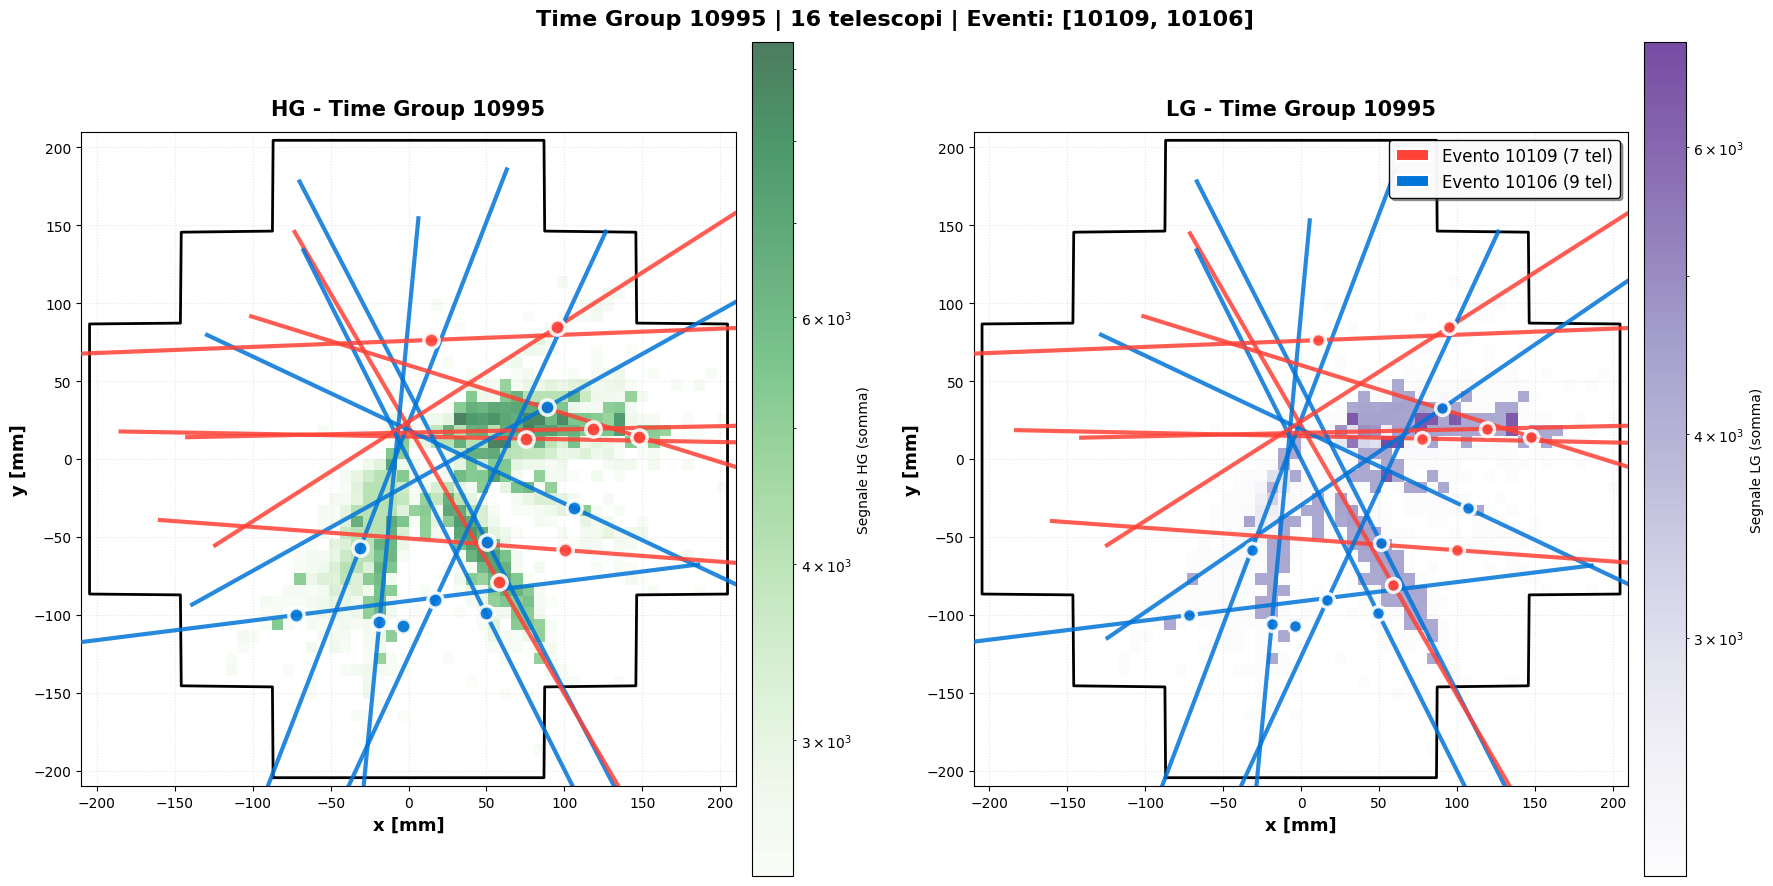

✓ Completato time_group 10995
  Rette per evento: {10109: 7, 10106: 9}


TIME GROUP 6883
Telescopi: 16 | Eventi: [15712 15710] | MCRUN: [220045]


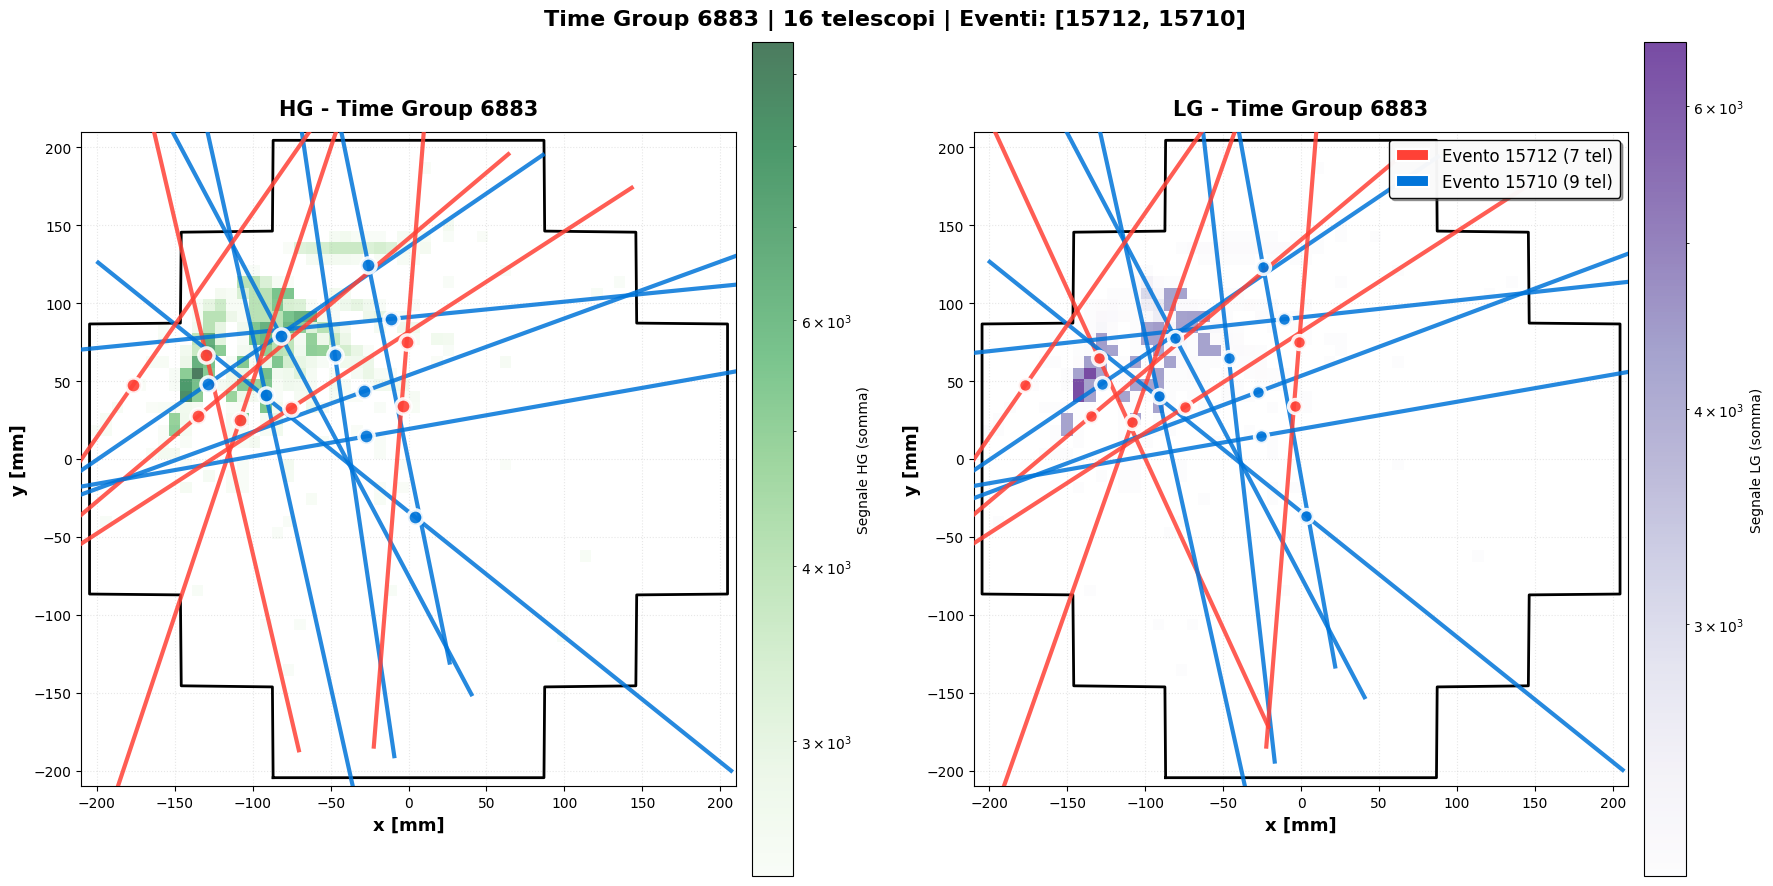

✓ Completato time_group 6883
  Rette per evento: {15712: 7, 15710: 9}



In [68]:
from matplotlib.colors import LogNorm
# Setup camera
xfp, yfp = at.utils.camera.get_xy_footprint()
y_pix, x_pix = at.utils.camera.get_pixels_position_matrix().T
x_pix = at.reshape(x_pix)
y_pix = at.reshape(y_pix)

# Prendi i primi 2 gruppi temporali misti
time_groups_to_plot = affected_time_groups[:2]

for time_group in time_groups_to_plot:
    
    # Estrai tutti gli eventi di questo gruppo temporale
    df_window = df_linked_events[df_linked_events['time_group'] == time_group].copy()
    
    # Informazioni sul gruppo
    unique_events = df_window['EVENT'].unique()
    unique_mcruns = df_window['MCRUN'].unique()
    
    print(f"\n{'='*70}")
    print(f"TIME GROUP {time_group}")
    print(f"Telescopi: {len(df_window)} | Eventi: {unique_events} | MCRUN: {unique_mcruns}")
    print(f"{'='*70}")
    
    # Ordina per shape
    df_window = df_window.sort_values(by='shape', ascending=False).reset_index(drop=True)
    
    # Inizializza array per sommare le immagini
    weights_hg = np.zeros_like(np.array(df_window['HG'].iloc[0]))
    weights_lg = np.zeros_like(np.array(df_window['LG'].iloc[0]))
    mask_tot = np.zeros((37, 64), dtype=bool)
    
    # Crea figura side-by-side
    fig, ax = plt.subplots(1, 2, figsize=(18, 9))
    
    # Lunghezza rette
    xmin, xmax = np.min(xfp), np.max(xfp)
    ymin, ymax = np.min(yfp), np.max(yfp)
    diag = np.sqrt((xmax - xmin)**2 + (ymax - ymin)**2)
    L = 0.45 * diag
    
    # Colori per eventi (più vivaci)
    colors = ['#FF4136', '#0074D9', '#2ECC40', '#FF851B']  # rosso, blu, verde, arancione
    event_color_map = {unique_events[i]: colors[i % len(colors)] for i in range(len(unique_events))}
    
    # Liste per contare rette per evento
    rette_per_evento = {ev: 0 for ev in unique_events}
    
    # Itera su tutti i telescopi del gruppo
    for idx, row in df_window.iterrows():
        
        hgev = np.array(row['HG'])
        lgev = np.array(row['LG'])
        ttpev = np.array(row['TTP'])
        
        # mask di pixel buoni
        pxmask = (hgev > 2400) & (ttpev < 255)
        
        if not np.any(pxmask):
            continue
        
        # Somma le immagini
        weights_hg[pxmask] += hgev[pxmask]
        weights_lg[pxmask] += lgev[pxmask]
        mask_tot |= pxmask
        
        # Centroidi
        meanx_hg = np.average(x_pix[pxmask].flatten(), weights=hgev[pxmask].flatten())
        meany_hg = np.average(y_pix[pxmask].flatten(), weights=hgev[pxmask].flatten())
        meanx_lg = np.average(x_pix[pxmask].flatten(), weights=lgev[pxmask].flatten())
        meany_lg = np.average(y_pix[pxmask].flatten(), weights=lgev[pxmask].flatten())
        
        # Covarianze
        cov_hg = np.cov([x_pix[pxmask].flatten(), y_pix[pxmask].flatten()], 
                        aweights=hgev[pxmask].flatten())
        cov_lg = np.cov([x_pix[pxmask].flatten(), y_pix[pxmask].flatten()], 
                        aweights=lgev[pxmask].flatten())
        
        # Parametri ellisse
        l1_hg = (cov_hg[0,0] + cov_hg[1,1])/2 + np.sqrt(((cov_hg[0,0] - cov_hg[1,1])/2)**2 + cov_hg[0,1]**2)
        theta_hg = np.arctan2(l1_hg - cov_hg[0,0], cov_hg[0,1])
        
        l1_lg = (cov_lg[0,0] + cov_lg[1,1])/2 + np.sqrt(((cov_lg[0,0] - cov_lg[1,1])/2)**2 + cov_lg[0,1]**2)
        theta_lg = np.arctan2(l1_lg - cov_lg[0,0], cov_lg[0,1])
        
        # Colore basato sull'evento
        color_ev = event_color_map[row['EVENT']]
        rette_per_evento[row['EVENT']] += 1
        
        # ===== HG (sinistra) =====
        ax[0].scatter(meanx_hg, meany_hg, s=120, color=color_ev, 
                      edgecolor='white', linewidth=2.5, zorder=6, alpha=0.9)
        
        x1 = meanx_hg - L * np.cos(theta_hg)
        y1 = meany_hg - L * np.sin(theta_hg)
        x2 = meanx_hg + L * np.cos(theta_hg)
        y2 = meany_hg + L * np.sin(theta_hg)
        ax[0].plot([x1, x2], [y1, y2], color=color_ev, linewidth=3, alpha=0.85, zorder=5)
        
        # ===== LG (destra) =====
        ax[1].scatter(meanx_lg, meany_lg, s=100, color=color_ev, 
                      edgecolor='white', linewidth=2.5, zorder=6, alpha=0.9)
        
        x1 = meanx_lg - L * np.cos(theta_lg)
        y1 = meany_lg - L * np.sin(theta_lg)
        x2 = meanx_lg + L * np.cos(theta_lg)
        y2 = meany_lg + L * np.sin(theta_lg)
        ax[1].plot([x1, x2], [y1, y2], color=color_ev, linewidth=3, alpha=0.85, zorder=5)
    
    # Heatmap somma
    weights_hg = np.array(weights_hg)
    weights_lg = np.array(weights_lg)
    
    h1 = ax[0].hist2d(x_pix[mask_tot].flatten(), y_pix[mask_tot].flatten(),
                      weights=weights_hg[mask_tot].flatten(), 
                      range=((-205, 205), (-205, 205)),
                      bins=7*8, cmap='Greens', alpha=0.7, norm=LogNorm())
    
    h2 = ax[1].hist2d(x_pix[mask_tot].flatten(), y_pix[mask_tot].flatten(),
                      weights=weights_lg[mask_tot].flatten(), 
                      range=((-205, 205), (-205, 205)),
                      bins=7*8, cmap='Purples', alpha=0.7, norm=LogNorm())
    
    # Footprint camera
    for a in ax:
        a.plot(xfp, yfp, 'k-', linewidth=2, zorder=2)
        a.set_xlim(-210, 210)
        a.set_ylim(-210, 210)
        a.set_aspect('equal')
        a.set_xlabel('x [mm]', fontsize=13, fontweight='bold')
        a.set_ylabel('y [mm]', fontsize=13, fontweight='bold')
        a.grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
    
    ax[0].set_title(f'HG - Time Group {time_group}', fontweight='bold', fontsize=15, pad=12)
    ax[1].set_title(f'LG - Time Group {time_group}', fontweight='bold', fontsize=15, pad=12)
    
    # Colorbar
    cbar1 = fig.colorbar(h1[3], ax=ax[0], label='Segnale HG (somma)', pad=0.02)
    cbar2 = fig.colorbar(h2[3], ax=ax[1], label='Segnale LG (somma)', pad=0.02)
    cbar1.ax.tick_params(labelsize=11)
    cbar2.ax.tick_params(labelsize=11)
    
    # Legenda eventi
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=event_color_map[ev], edgecolor='white', linewidth=1.5,
              label=f'Evento {ev} ({rette_per_evento[ev]} tel)')
        for ev in unique_events
    ]
    ax[1].legend(handles=legend_elements, loc='upper right', fontsize=12, 
                 framealpha=0.95, edgecolor='black', fancybox=True, shadow=True)
    
    plt.suptitle(f'Time Group {time_group} | {len(df_window)} telescopi | Eventi: {list(unique_events)}',
                 fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()
    
    print(f"✓ Completato time_group {time_group}")
    print(f"  Rette per evento: {rette_per_evento}\n")

Primi 5 gruppi per energia:
   time_group  group_shape
0         176     10577538
1        1863     10428828
2        2456     20946732
3        2473     10483435
4        4866      5278770

TIME GROUP 10984
Telescopi: 5 | Eventi: [6418] | MCRUN: [220272]


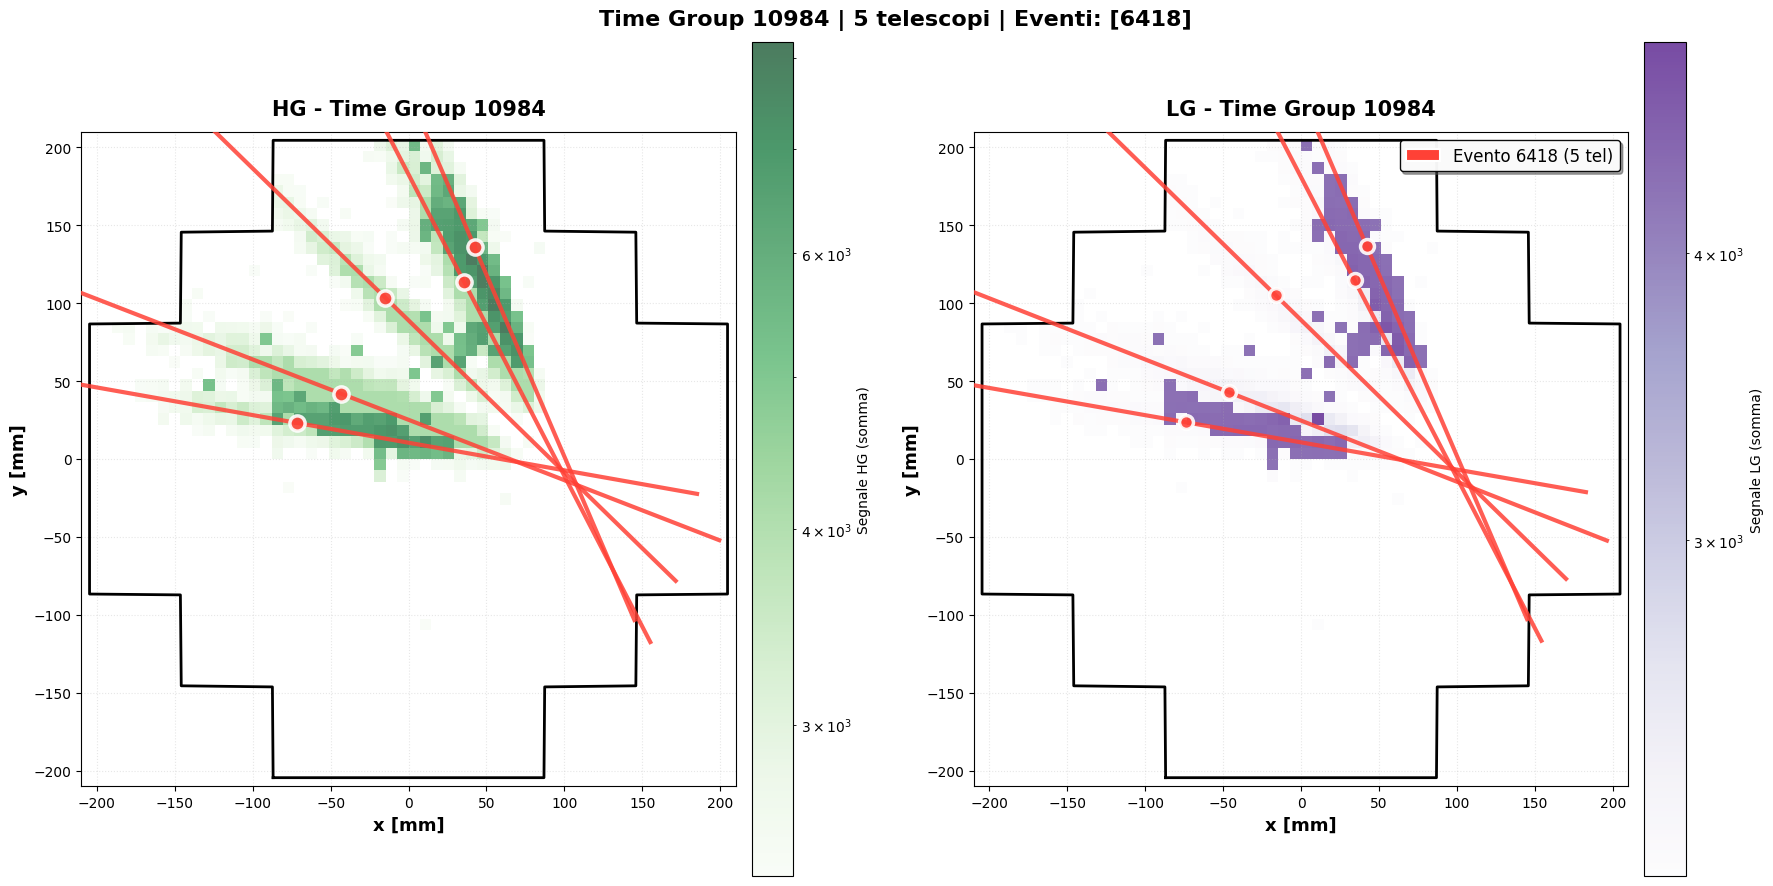

✓ Completato time_group 10984
  Rette per evento: {6418: 5}


TIME GROUP 2456
Telescopi: 4 | Eventi: [47418] | MCRUN: [220016]


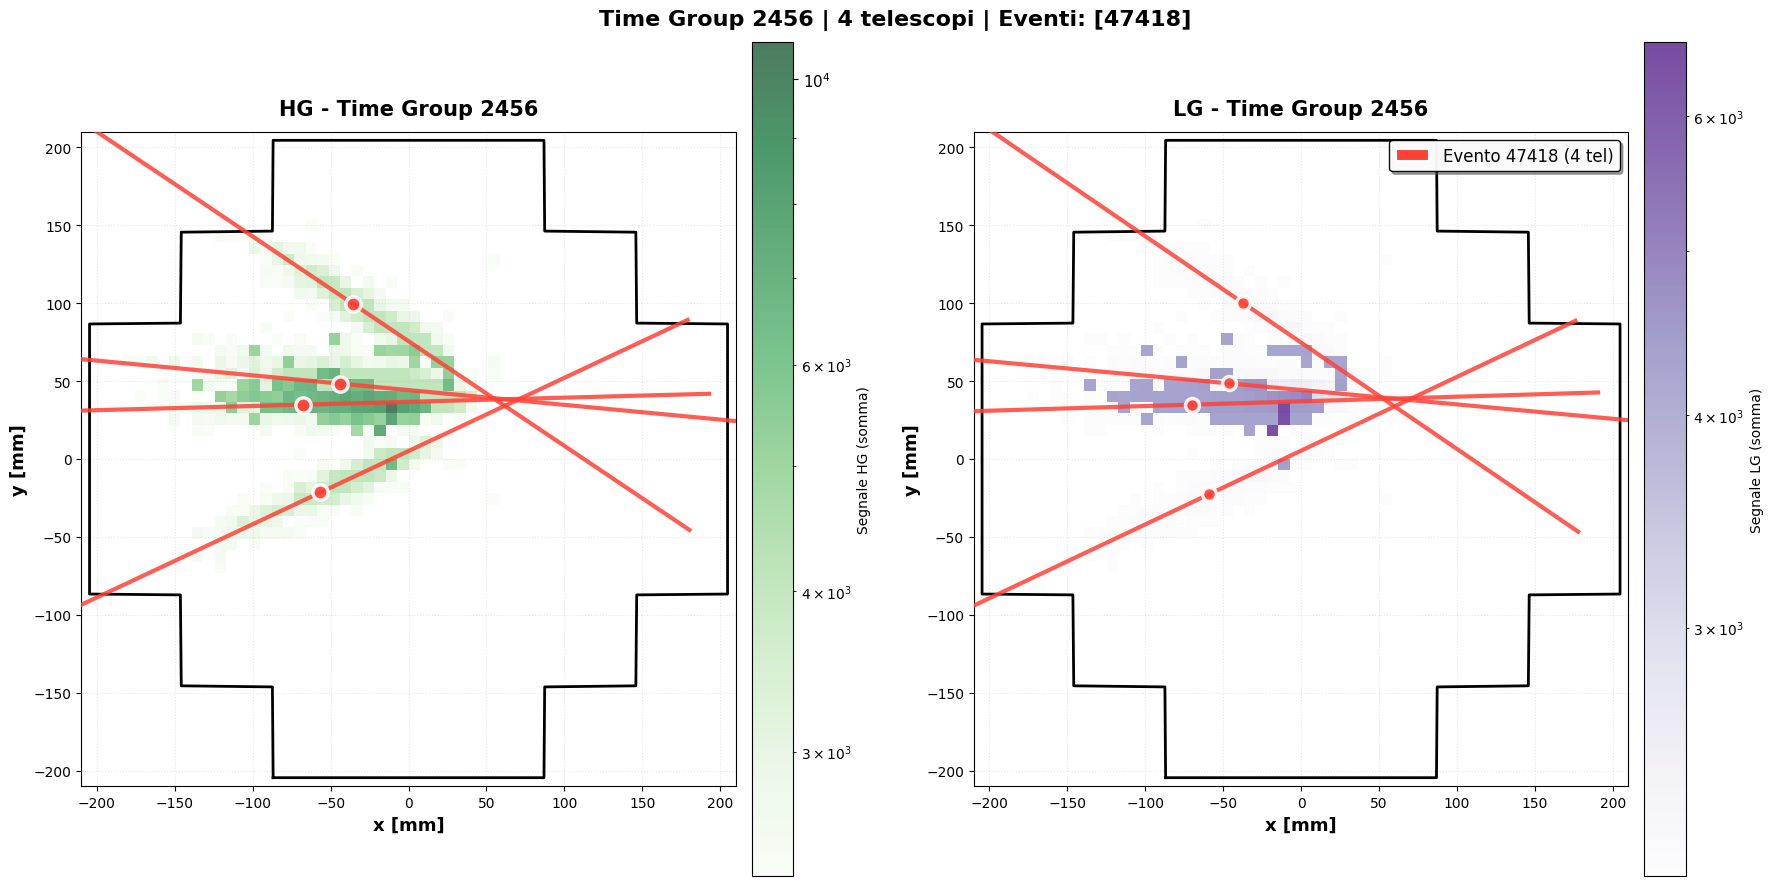

✓ Completato time_group 2456
  Rette per evento: {47418: 4}



In [81]:
shape_threshold = 5.2e6  # MODIFICA QUESTA SOGLIA

# 1️⃣ Filtra eventi singoli per shape
df_linked_events_filtered = df_linked_events[df_linked_events['shape'] > shape_threshold].copy()

# 2️⃣ Calcola l'energia totale per ciascun time_group
group_energy = df_linked_events_filtered.groupby('time_group')['shape'].sum().reset_index()
group_energy.rename(columns={'shape': 'group_shape'}, inplace=True)  # rinomina la colonna per evitare conflitti

# 3️⃣ Merge: aggiungi group_shape a ciascun evento del gruppo
df_linked_events_filtered = df_linked_events_filtered.merge(group_energy, on='time_group')

# 4️⃣ Ordina i gruppi per energia decrescente
df_linked_events_filtered = df_linked_events_filtered.sort_values('group_shape', ascending=False)

# 5️⃣ Prepara lista dei time_group ordinati per energia
affected_time_groups = df_linked_events_filtered['time_group'].drop_duplicates().values


print("Primi 5 gruppi per energia:")
print(group_energy.head())
# Setup camera
xfp, yfp = at.utils.camera.get_xy_footprint()
y_pix, x_pix = at.utils.camera.get_pixels_position_matrix().T
x_pix = at.reshape(x_pix)
y_pix = at.reshape(y_pix)

# Prendi i primi 2 gruppi temporali misti
time_groups_to_plot = affected_time_groups[:2]

for time_group in time_groups_to_plot:
    
    # Estrai tutti gli eventi di questo gruppo temporale
    df_window = df_linked_events_filtered[df_linked_events_filtered['time_group'] == time_group].copy()
    
    # Informazioni sul gruppo
    unique_events = df_window['EVENT'].unique()
    unique_mcruns = df_window['MCRUN'].unique()
    
    print(f"\n{'='*70}")
    print(f"TIME GROUP {time_group}")
    print(f"Telescopi: {len(df_window)} | Eventi: {unique_events} | MCRUN: {unique_mcruns}")
    print(f"{'='*70}")
    
    # Ordina per shape
    df_window = df_window.sort_values(by='shape', ascending=False).reset_index(drop=True)
    
    # Inizializza array per sommare le immagini
    weights_hg = np.zeros_like(np.array(df_window['HG'].iloc[0]))
    weights_lg = np.zeros_like(np.array(df_window['LG'].iloc[0]))
    mask_tot = np.zeros((37, 64), dtype=bool)
    
    # Crea figura side-by-side
    fig, ax = plt.subplots(1, 2, figsize=(18, 9))
    
    # Lunghezza rette
    xmin, xmax = np.min(xfp), np.max(xfp)
    ymin, ymax = np.min(yfp), np.max(yfp)
    diag = np.sqrt((xmax - xmin)**2 + (ymax - ymin)**2)
    L = 0.45 * diag
    
    # Colori per eventi (più vivaci)
    colors = ['#FF4136', '#0074D9', '#2ECC40', '#FF851B']  # rosso, blu, verde, arancione
    event_color_map = {unique_events[i]: colors[i % len(colors)] for i in range(len(unique_events))}
    
    # Liste per contare rette per evento
    rette_per_evento = {ev: 0 for ev in unique_events}
    
    # Itera su tutti i telescopi del gruppo
    for idx, row in df_window.iterrows():
        
        hgev = np.array(row['HG'])
        lgev = np.array(row['LG'])
        ttpev = np.array(row['TTP'])
        
        # mask di pixel buoni
        pxmask = (hgev > 2400) & (ttpev < 255)
        
        if not np.any(pxmask):
            continue
        
        # Somma le immagini
        weights_hg[pxmask] += hgev[pxmask]
        weights_lg[pxmask] += lgev[pxmask]
        mask_tot |= pxmask
        
        # Centroidi
        meanx_hg = np.average(x_pix[pxmask].flatten(), weights=hgev[pxmask].flatten())
        meany_hg = np.average(y_pix[pxmask].flatten(), weights=hgev[pxmask].flatten())
        meanx_lg = np.average(x_pix[pxmask].flatten(), weights=lgev[pxmask].flatten())
        meany_lg = np.average(y_pix[pxmask].flatten(), weights=lgev[pxmask].flatten())
        
        # Covarianze
        cov_hg = np.cov([x_pix[pxmask].flatten(), y_pix[pxmask].flatten()], 
                        aweights=hgev[pxmask].flatten())
        cov_lg = np.cov([x_pix[pxmask].flatten(), y_pix[pxmask].flatten()], 
                        aweights=lgev[pxmask].flatten())
        
        # Parametri ellisse
        l1_hg = (cov_hg[0,0] + cov_hg[1,1])/2 + np.sqrt(((cov_hg[0,0] - cov_hg[1,1])/2)**2 + cov_hg[0,1]**2)
        theta_hg = np.arctan2(l1_hg - cov_hg[0,0], cov_hg[0,1])
        
        l1_lg = (cov_lg[0,0] + cov_lg[1,1])/2 + np.sqrt(((cov_lg[0,0] - cov_lg[1,1])/2)**2 + cov_lg[0,1]**2)
        theta_lg = np.arctan2(l1_lg - cov_lg[0,0], cov_lg[0,1])
        
        # Colore basato sull'evento
        color_ev = event_color_map[row['EVENT']]
        rette_per_evento[row['EVENT']] += 1
        
        # ===== HG (sinistra) =====
        ax[0].scatter(meanx_hg, meany_hg, s=120, color=color_ev, 
                      edgecolor='white', linewidth=2.5, zorder=6, alpha=0.9)
        
        x1 = meanx_hg - L * np.cos(theta_hg)
        y1 = meany_hg - L * np.sin(theta_hg)
        x2 = meanx_hg + L * np.cos(theta_hg)
        y2 = meany_hg + L * np.sin(theta_hg)
        ax[0].plot([x1, x2], [y1, y2], color=color_ev, linewidth=3, alpha=0.85, zorder=5)
        
        # ===== LG (destra) =====
        ax[1].scatter(meanx_lg, meany_lg, s=100, color=color_ev, 
                      edgecolor='white', linewidth=2.5, zorder=6, alpha=0.9)
        
        x1 = meanx_lg - L * np.cos(theta_lg)
        y1 = meany_lg - L * np.sin(theta_lg)
        x2 = meanx_lg + L * np.cos(theta_lg)
        y2 = meany_lg + L * np.sin(theta_lg)
        ax[1].plot([x1, x2], [y1, y2], color=color_ev, linewidth=3, alpha=0.85, zorder=5)
    
    # Heatmap somma
    weights_hg = np.array(weights_hg)
    weights_lg = np.array(weights_lg)
    
    h1 = ax[0].hist2d(x_pix[mask_tot].flatten(), y_pix[mask_tot].flatten(),
                      weights=weights_hg[mask_tot].flatten(), 
                      range=((-205, 205), (-205, 205)),
                      bins=7*8, cmap='Greens', alpha=0.7, norm=LogNorm())
    
    h2 = ax[1].hist2d(x_pix[mask_tot].flatten(), y_pix[mask_tot].flatten(),
                      weights=weights_lg[mask_tot].flatten(), 
                      range=((-205, 205), (-205, 205)),
                      bins=7*8, cmap='Purples', alpha=0.7, norm=LogNorm())
    
    # Footprint camera
    for a in ax:
        a.plot(xfp, yfp, 'k-', linewidth=2, zorder=2)
        a.set_xlim(-210, 210)
        a.set_ylim(-210, 210)
        a.set_aspect('equal')
        a.set_xlabel('x [mm]', fontsize=13, fontweight='bold')
        a.set_ylabel('y [mm]', fontsize=13, fontweight='bold')
        a.grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
    
    ax[0].set_title(f'HG - Time Group {time_group}', fontweight='bold', fontsize=15, pad=12)
    ax[1].set_title(f'LG - Time Group {time_group}', fontweight='bold', fontsize=15, pad=12)
    
    # Colorbar
    cbar1 = fig.colorbar(h1[3], ax=ax[0], label='Segnale HG (somma)', pad=0.02)
    cbar2 = fig.colorbar(h2[3], ax=ax[1], label='Segnale LG (somma)', pad=0.02)
    cbar1.ax.tick_params(labelsize=11)
    cbar2.ax.tick_params(labelsize=11)
    
    # Legenda eventi
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=event_color_map[ev], edgecolor='white', linewidth=1.5,
              label=f'Evento {ev} ({rette_per_evento[ev]} tel)')
        for ev in unique_events
    ]
    ax[1].legend(handles=legend_elements, loc='upper right', fontsize=12, 
                 framealpha=0.95, edgecolor='black', fancybox=True, shadow=True)
    
    plt.suptitle(f'Time Group {time_group} | {len(df_window)} telescopi | Eventi: {list(unique_events)}',
                 fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()
    
    print(f"✓ Completato time_group {time_group}")
    print(f"  Rette per evento: {rette_per_evento}\n")

In [54]:
# Trova gli indici dove delta_t < 1000
# Calcola delta_t


def principal_axis(cov):
            l1 = (cov[0,0] + cov[1,1])/2 + np.sqrt(
                ((cov[0,0] - cov[1,1])/2)**2 + cov[0,1]**2)
            theta = np.arctan2(l1 - cov[0,0], cov[0,1])
            return l1, theta
#raccolgo i dati delle rette divisi per ogni (event,mcrun)
#df_all_sorted=df_all_sorted[df_all_sorted["shape"]>5.16e6]
#df_all_sorted=df_all_sorted[df_all_sorted["num_tel"]>=3]

print(len(df_all_sorted))

xfp, yfp = at.utils.camera.get_xy_footprint()
y_pix, x_pix = at.utils.camera.get_pixels_position_matrix().T
x_pix = at.reshape(x_pix)
y_pix = at.reshape(y_pix)

#rette_hg=[]
#rette_lg=[]
results = []

for time_group, df_evt in df_all_sorted.groupby('time_group'):
    event = df_evt['EVENT'].unique()
    mcrun = df_evt['MCRUN'].unique()
    for iv, row in df_evt.iterrows():

        itel = row["TEL_ID"]
        hgev = np.array(row["HG"])
        lgev = np.array(row["LG"])
        ttpev = np.array(row["TTP"])

        # filtro temporale
        pxmask = (hgev > 2400) & (ttpev < 255)
        if  np.sum(pxmask) == 0:
            continue
        # SIGMA-CLIPPING
    
        xx = x_pix[pxmask].flatten()
        yy = y_pix[pxmask].flatten()
        w_hg = hgev[pxmask].flatten()
        w_lg = lgev[pxmask].flatten()

        mx0 = np.average(xx, weights=w_hg)
        my0 = np.average(yy, weights=w_hg)

        r = np.sqrt((xx - mx0)**2 + (yy - my0)**2)

        r_clip, low, high = sc.sigmaclip(r, low=2., high=2.)
        keep = (r >= low) & (r <= high)

        xx_sc = xx[keep]
        yy_sc = yy[keep]
        w_hg_sc = w_hg[keep]
        w_lg_sc = w_lg[keep]
        # ---------- centroidi ----------
        meanx_hg = np.average(xx_sc, weights=w_hg_sc)
        meany_hg = np.average(yy_sc, weights=w_hg_sc)

        meanx_lg = np.average(xx_sc, weights=w_lg_sc)
        meany_lg = np.average(yy_sc, weights=w_lg_sc)

        # ---------- covarianze ----------
        cov_hg = np.cov([xx_sc, yy_sc], aweights=w_hg_sc)
        cov_lg = np.cov([xx_sc, yy_sc], aweights=w_lg_sc)
        # autovalori + direzione
        

        l1_hg, theta_hg = principal_axis(cov_hg)
        l1_lg, theta_lg = principal_axis(cov_lg)

        results.append({
            "event": event,
            "mcrun": mcrun,
            "HG": {
                "p0": np.array([meanx_hg, meany_hg]),
                "d":  np.array([np.cos(theta_hg), np.sin(theta_hg)]),
                "l1": l1_hg,
                "tel": itel
            },
            "LG": {
                "p0": np.array([meanx_lg, meany_lg]),
                "d":  np.array([np.cos(theta_lg), np.sin(theta_lg)]),
                "l1": l1_lg,
                "tel": itel
            }
        })


38476


/tmp/ipykernel_532286/2018823740.py:66: RuntimeWarning: Degrees of freedom <= 0 for slice
  cov_hg = np.cov([xx_sc, yy_sc], aweights=w_hg_sc)
/home/matfra/miniconda3/envs/astrienv/lib/python3.10/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/home/matfra/miniconda3/envs/astrienv/lib/python3.10/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
/tmp/ipykernel_532286/2018823740.py:67: RuntimeWarning: Degrees of freedom <= 0 for slice
  cov_lg = np.cov([xx_sc, yy_sc], aweights=w_lg_sc)
/tmp/ipykernel_532286/2018823740.py:7: RuntimeWarning: invalid value encountered in scalar subtract
  ((cov[0,0] - cov[1,1])/2)**2 + cov[0,1]**2)


In [28]:
# ======================= FUNZIONI GEOMETRICHE =======================

def intersection(p1, d1, p2, d2, eps_ang=1e-1, eps_det=1e-6):
    """
    p1, p2 = punti (2,)
    d1, d2 = direzioni (2,)
    """

    # --- controllo quasi-parallelismo ---
    det_dir = d1[0]*d2[1] - d1[1]*d2[0]
    if abs(det_dir) < eps_ang:        # <<< taglio fisico
        return None

    A = np.array([d1, -d2]).T
    b = p2 - p1

    detA = np.linalg.det(A)
    if abs(detA) < eps_det:           # <<< sicurezza numerica
        return None

    t = np.linalg.solve(A, b)[0]
    return p1 + t * d1
def d_punto_retta(P, p0, d):
    norm_d = np.linalg.norm(d)
    if norm_d == 0:
        return np.nan
    d_unit = d / norm_d
    v = P - p0
    return abs(v[0] * d_unit[1] - v[1] * d_unit[0])
def d_punto_retta_vec(P, p0, d):
    """
    distanza di N rette da un punto
    """
    norm_d = np.linalg.norm(d, axis=1)
    mask = norm_d > 0
    d_unit = np.zeros_like(d)
    d_unit[mask] = d[mask] / norm_d[mask, None]
    v = P - p0
    return np.abs(v[:, 0] * d_unit[:, 1] - v[:, 1] * d_unit[:, 0])


In [39]:
# ======================= CALCOLO INTERSEZIONI =======================
inters_hg = []
inters_lg = []
dfR = pd.DataFrame(results)
print(dfR.head(10))
for (event, mcrun), df_evt in dfR.groupby(["event", "mcrun"]):

    rette_hg = df_evt["HG"].values
    rette_lg = df_evt["LG"].values

    # ---------- HG ----------
    for i in range(len(rette_hg)):
        for j in range(i+1, len(rette_hg)):

            if rette_hg[i]["tel"] == rette_hg[j]["tel"]:
                continue

            d1 = rette_hg[i]["d"]
            d2 = rette_hg[j]["d"]

            P = intersection(rette_hg[i]["p0"], d1,rette_hg[j]["p0"], d2)

            if P is None:
                continue

            inters_hg.append({
                "event": event,
                "mcrun": mcrun,
                "P": P,
                "pair": (i, j)
            })

    # ---------- LG ----------
    for i in range(len(rette_lg)):
        for j in range(i+1, len(rette_lg)):

            if rette_lg[i]["tel"] == rette_lg[j]["tel"]:
                continue

            d1 = rette_lg[i]["d"]
            d2 = rette_lg[j]["d"]

            P = intersection(
                rette_lg[i]["p0"], d1,
                rette_lg[j]["p0"], d2
            )

            if P is None:
                continue

            inters_lg.append({
                "event": event,
                "mcrun": mcrun,
                "P": P,
                "pair": (i, j)
            })

df_int_hg = pd.DataFrame(inters_hg)
df_int_lg = pd.DataFrame(inters_lg)
print("NaN values:", np.isnan(P).sum())

   event   mcrun                                                 HG  \
0    100  220048  {'p0': [-24.88987598182088, 161.3594471274021]...   
1    100  220048  {'p0': [-10.329300554293276, 127.0725005792614...   
2    100  220048  {'p0': [-58.80982473867596, 125.09572229965158...   
3    100  220048  {'p0': [21.10341851749793, -1.0353661339211897...   
4    100  220284  {'p0': [105.82230171052109, 129.18807823550426...   
5    100  220284  {'p0': [105.02361195853891, 112.16903638256461...   
6    100  220284  {'p0': [-10.477072243945939, 9.769490073403308...   
7    100  220290  {'p0': [73.48620411015911, 62.96802322624897],...   
8    100  220290  {'p0': [12.496402605990585, -10.69105249026424...   
9    100  220290  {'p0': [-1.9659358351197311, -97.7317949889492...   

                                                  LG  
0  {'p0': [-25.458918085539715, 161.5807995519348...  
1  {'p0': [-10.372298221411114, 126.924731219648]...  
2  {'p0': [-58.75167242827151, 125.08413163051084... 

/home/matfra/miniconda3/envs/astrienv/lib/python3.10/site-packages/numpy/linalg/linalg.py:2180: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


NaN values: 0


In [35]:
from sklearn.cluster import DBSCAN

epsilon = 295
min_samples = 1
revent_map = {}
revent_counter = 0
# ======================= HG =======================
dist_hg = []
delta_hg = []

for (event, mcrun), df_evt in df_int_hg.groupby(["event", "mcrun"]):
    # -------- REVENT --------
    if (event, mcrun) not in revent_map:
        revent_map[(event, mcrun)] = revent_counter
        revent_counter += 1
    revent = revent_map[(event, mcrun)]
    # ------------------------

    P = np.vstack(df_evt["P"].values)
    if np.isnan(P).sum() !=0:
        continue

    labels = DBSCAN(eps=epsilon, min_samples=min_samples).fit_predict(P)
    cl_labels = set(labels) - {-1}
    if not cl_labels:
        continue

    dfR_evt = dfR.loc[
        (dfR["event"] == event) & (dfR["mcrun"] == mcrun),
        "HG"
    ]

    p0  = np.array([r["p0"]  for r in dfR_evt])
    d   = np.array([r["d"]   for r in dfR_evt])
    tel = np.array([r["tel"] for r in dfR_evt])

    for lab in cl_labels:

        mask = labels == lab
        Pcl  = P[mask]
        dfP  = df_evt.loc[mask]

        # ---------- pesi angolari (VETTORIALI) ----------
        pairs = np.array(dfP["pair"].tolist())      # (N,2)
        d1 = d[pairs[:, 0]]
        d2 = d[pairs[:, 1]]
        
        w = (d1[:, 0]*d2[:, 1] - d1[:, 1]*d2[:, 0])**2   # sin^2(theta)
        pairs = np.array(dfP["pair"].tolist())      # (N,2)
        d1 = d[pairs[:, 0]]
        d2 = d[pairs[:, 1]]

        det = d1[:, 0]*d2[:, 1] - d1[:, 1]*d2[:, 0]

        mask = np.abs(det) >= 1e-1    # TAGLIO NUMERICO

        if not np.any(mask):
            continue

        w   = det[mask]**2
        Pcl = Pcl[mask]
        # ---------- stimatori ----------
        P_simple = np.mean(Pcl, axis=0)
        P_weight = np.average(Pcl, axis=0, weights=w)
        P_median = np.median(Pcl, axis=0)

        # ---------- diagnostica ----------
        delta_hg.append(np.linalg.norm(P_weight - P_simple))

        # ---------- distanze ----------
        dist_w = d_punto_retta_vec(P_weight, p0, d)
        dist_m = d_punto_retta_vec(P_median, p0, d)
        dist_s = d_punto_retta_vec(P_simple, p0, d)
        for t, ds, dw, dm in zip(tel, dist_s, dist_w, dist_m):
            dist_hg.append({
                "revent": revent, 
                "event": event,
                "mcrun": mcrun,
                "cluster": lab,
                "tel": t,
                "P_simple": P_simple.copy(),
                "P_weight": P_weight.copy(),
                "P_median": P_median.copy(),
                "d_simple": ds,
                "d_weight": dw,
                "d_median": dm
            })
                

df_dist_hg = pd.DataFrame(dist_hg)


# ======================= LG =======================
dist_lg = []
delta_lg = []

for (event, mcrun), df_evt in df_int_lg.groupby(["event", "mcrun"]):
    # -------- REVENT --------
    if (event, mcrun) not in revent_map:
        revent_map[(event, mcrun)] = revent_counter
        revent_counter += 1
    revent = revent_map[(event, mcrun)]
    # ------------------------
    P = np.vstack(df_evt["P"].values)
    if P.shape[0] < min_samples:
        continue

    labels = DBSCAN(eps=epsilon, min_samples=min_samples).fit_predict(P)
    cl_labels = set(labels) - {-1}
    if not cl_labels:
        continue

    dfR_evt = dfR.loc[
        (dfR["event"] == event) & (dfR["mcrun"] == mcrun),
        "LG"
    ]

    p0  = np.array([r["p0"]  for r in dfR_evt])
    d   = np.array([r["d"]   for r in dfR_evt])
    tel = np.array([r["tel"] for r in dfR_evt])

    for lab in cl_labels:

        mask = labels == lab
        Pcl  = P[mask]
        dfP  = df_evt.loc[mask]

        pairs = np.array(dfP["pair"].tolist())
        d1 = d[pairs[:, 0]]
        d2 = d[pairs[:, 1]]

        w = (d1[:, 0]*d2[:, 1] - d1[:, 1]*d2[:, 0])**2

        P_simple = np.mean(Pcl, axis=0)
        P_weight = np.average(Pcl, axis=0, weights=w)
        P_median = np.median(Pcl, axis=0)

        delta_lg.append(np.linalg.norm(P_weight - P_simple))

        dist_w = d_punto_retta_vec(P_weight, p0, d)
        dist_m = d_punto_retta_vec(P_median, p0, d)
        dist_s = d_punto_retta_vec(P_simple, p0, d)
        for t, ds, dw, dm in zip(tel, dist_s, dist_w, dist_m):
            dist_lg.append({
                "revent": revent,
                "event": event,
                "mcrun": mcrun,
                "cluster": lab,
                "tel": t,
                "P_simple": P_simple.copy(),
                "P_weight": P_weight.copy(),
                "P_median": P_median.copy(),
                "d_simple": ds,
                "d_weight": dw,
                "d_median": dm
            })

df_dist_lg = pd.DataFrame(dist_lg)


ValueError: Input X contains NaN.
DBSCAN does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

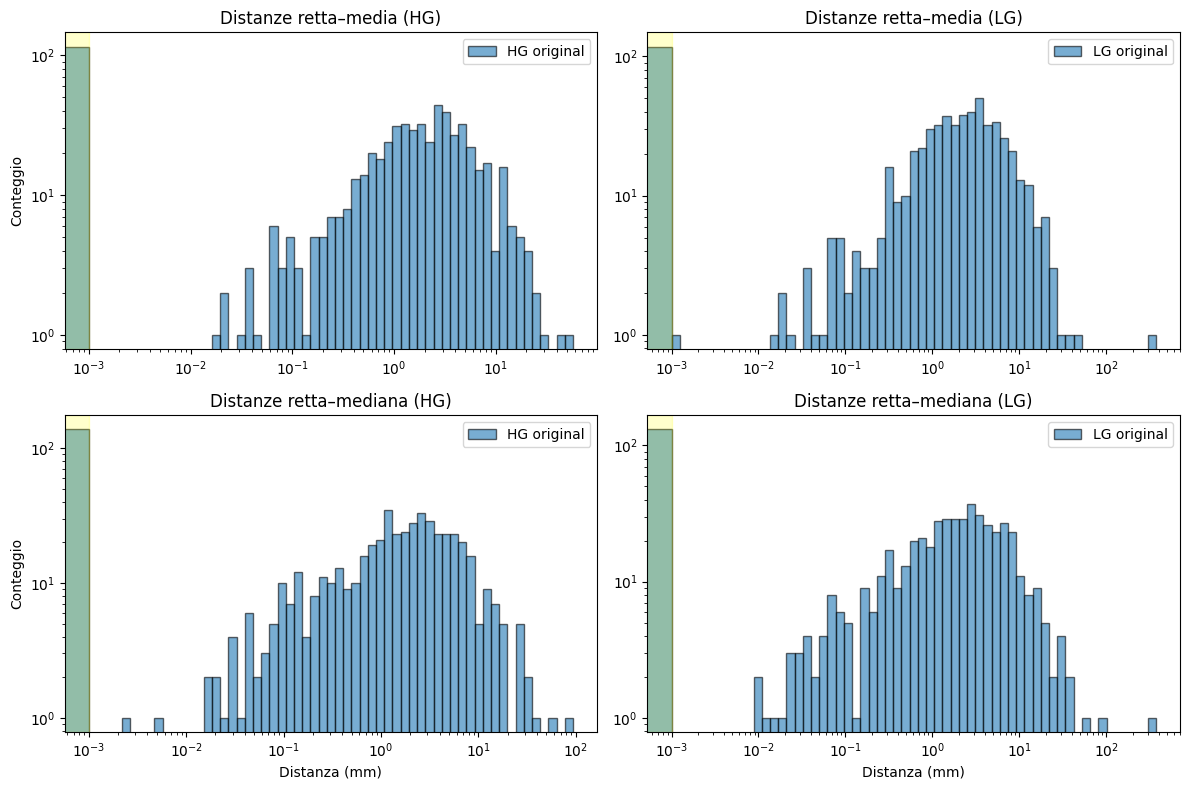

In [31]:
zero_threshold = 0.001
n_bins = 60

def smart_bins(data, n_bins=n_bins, zero_threshold=zero_threshold):
    """Crea bins logaritmici + bin speciale per valori ~0"""
    bin_zero = [0, zero_threshold]
    log_bins = np.logspace(np.log10(zero_threshold), np.log10(data.max()*1.1), n_bins)
    return np.unique(np.concatenate([bin_zero, log_bins]))

# ===================== ESTRAZIONE DISTANZE =====================
d_mean_hg   = df_dist_hg["d_weight"].values
d_median_hg = df_dist_hg["d_median"].values
d_mean_lg   = df_dist_lg["d_weight"].values
d_median_lg = df_dist_lg["d_median"].values


# filtro valori validi (>0 e finiti)
datasets = [d_mean_hg, d_median_hg, d_mean_lg, d_median_lg,]

datasets = [d[np.isfinite(d) & (d > 0)] for d in datasets]
d_mean_hg, d_median_hg, d_mean_lg, d_median_lg = datasets

# ===================== BINS COMUNI =====================
# Calcoliamo un bin comune per ogni tipo di distanza
bins_mean_hg   = smart_bins(np.concatenate([d_mean_hg, d_mean_hg]))
bins_median_hg = smart_bins(np.concatenate([d_median_hg, d_median_hg]))
bins_mean_lg   = smart_bins(np.concatenate([d_mean_lg, d_mean_lg]))
bins_median_lg = smart_bins(np.concatenate([d_median_lg, d_median_lg]))

# ===================== PLOT COMPARATIVO =====================
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=False, sharey=False)

# -------------------- HG Mean --------------------
axes[0,0].hist(d_mean_hg, bins=bins_mean_hg, edgecolor='black', alpha=0.6, label='HG original')
axes[0,0].set_title("Distanze retta–media (HG)")
axes[0,0].set_ylabel("Conteggio")
axes[0,0].legend()

# -------------------- HG Median --------------------
axes[1,0].hist(d_median_hg, bins=bins_median_hg, edgecolor='black', alpha=0.6, label='HG original')
axes[1,0].set_title("Distanze retta–mediana (HG)")
axes[1,0].set_ylabel("Conteggio")
axes[1,0].set_xlabel("Distanza (mm)")
axes[1,0].legend()

# -------------------- LG Mean --------------------
axes[0,1].hist(d_mean_lg, bins=bins_mean_lg, edgecolor='black', alpha=0.6, label='LG original')
axes[0,1].set_title("Distanze retta–media (LG)")
axes[0,1].legend()

# -------------------- LG Median --------------------
axes[1,1].hist(d_median_lg, bins=bins_median_lg, edgecolor='black', alpha=0.6, label='LG original')
axes[1,1].set_title("Distanze retta–mediana (LG)")
axes[1,1].set_xlabel("Distanza (mm)")
axes[1,1].legend()

# scala log su entrambi gli assi + evidenzia bin ~0
for ax in axes.flat:
    ax.axvspan(0, zero_threshold, alpha=0.2, color='yellow')
    ax.set_xscale("log")
    ax.set_yscale("log")

plt.tight_layout()
plt.show()


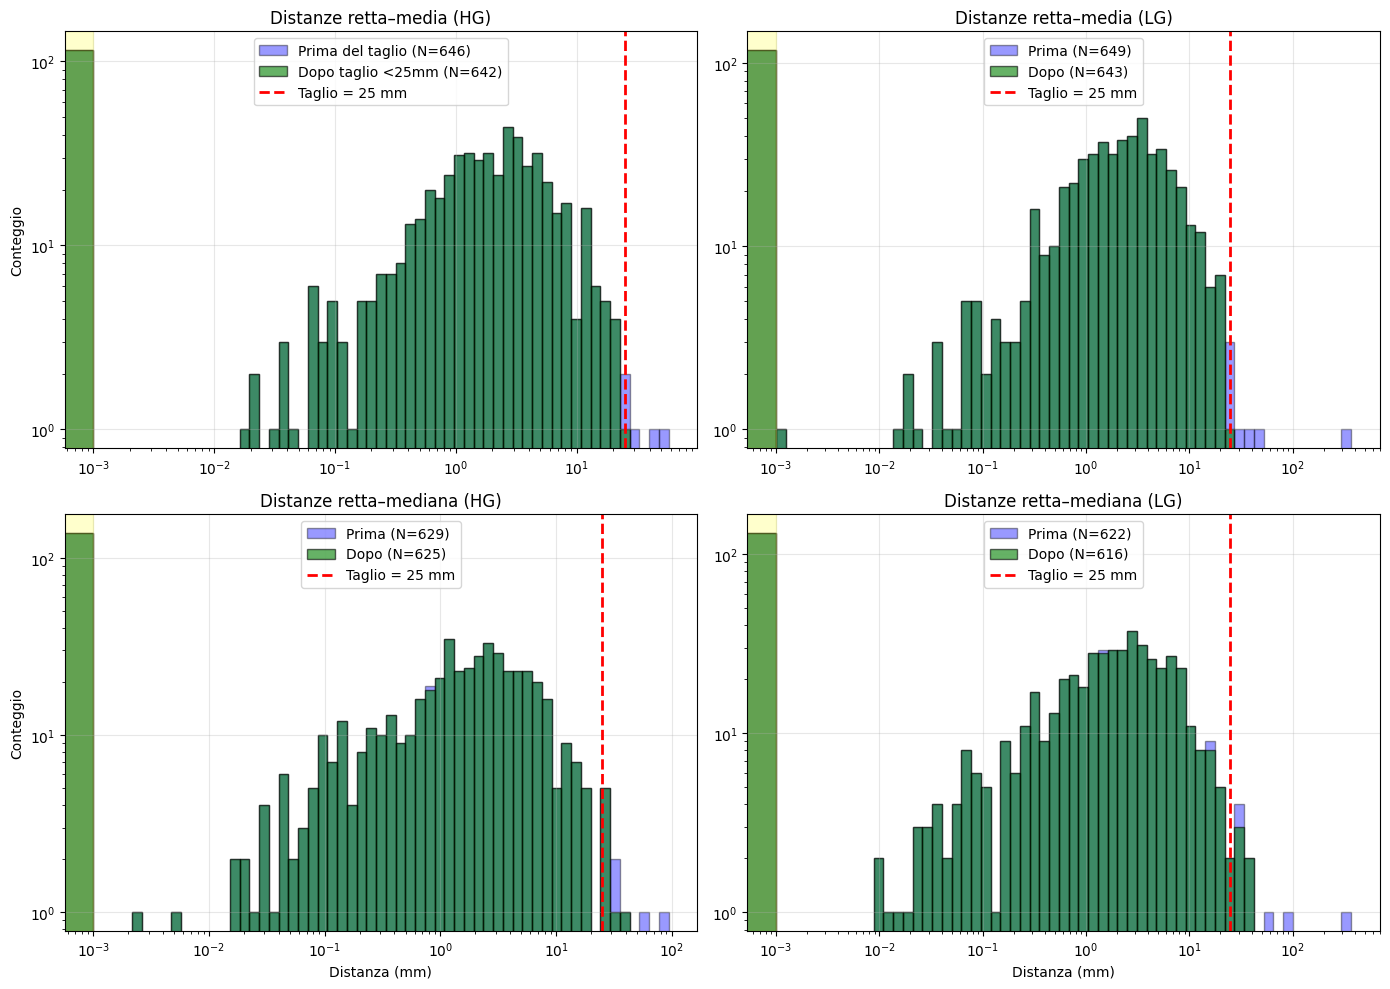


STATISTICHE PRIMA E DOPO IL TAGLIO

HG Mean:
  Prima:  N=646, mediana=1.39 mm
  Dopo:   N=642, mediana=1.36 mm
  Rimossi: 4 (0.6%)

HG Median:
  Prima:  N=629, mediana=1.06 mm
  Dopo:   N=625, mediana=1.06 mm
  Rimossi: 4 (0.6%)

LG Mean:
  Prima:  N=649, mediana=1.57 mm
  Dopo:   N=643, mediana=1.56 mm
  Rimossi: 6 (0.9%)

LG Median:
  Prima:  N=622, mediana=1.21 mm
  Dopo:   N=616, mediana=1.17 mm
  Rimossi: 6 (1.0%)


In [32]:
# ===================== DEFINISCI IL TAGLIO =====================
distance_cut = 25  # mm

# ===================== APPLICA IL TAGLIO =====================
# Opzione 1: Taglia sui dataframe originali
df_dist_hg_cut = df_dist_hg[df_dist_hg["d_weight"] < distance_cut].copy()
df_dist_lg_cut = df_dist_lg[df_dist_lg["d_weight"] < distance_cut].copy()

# Estrai le distanze dopo il taglio
d_mean_hg_cut   = df_dist_hg_cut["d_weight"].values
d_median_hg_cut = df_dist_hg_cut["d_median"].values
d_mean_lg_cut   = df_dist_lg_cut["d_weight"].values
d_median_lg_cut = df_dist_lg_cut["d_median"].values

# Filtra valori validi
datasets_cut = [d_mean_hg_cut, d_median_hg_cut, d_mean_lg_cut, d_median_lg_cut]
datasets_cut = [d[np.isfinite(d) & (d > 0)] for d in datasets_cut]
d_mean_hg_cut, d_median_hg_cut, d_mean_lg_cut, d_median_lg_cut = datasets_cut

# ===================== PLOT COMPARATIVO PRIMA/DOPO =====================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# -------------------- HG Mean --------------------
axes[0,0].hist(d_mean_hg, bins=bins_mean_hg, edgecolor='black', alpha=0.4, 
               label=f'Prima del taglio (N={len(d_mean_hg)})', color='blue')
axes[0,0].hist(d_mean_hg_cut, bins=bins_mean_hg, edgecolor='black', alpha=0.6, 
               label=f'Dopo taglio <{distance_cut}mm (N={len(d_mean_hg_cut)})', color='green')
axes[0,0].axvline(distance_cut, color='red', linestyle='--', linewidth=2, label=f'Taglio = {distance_cut} mm')
axes[0,0].set_title("Distanze retta–media (HG)")
axes[0,0].set_ylabel("Conteggio")
axes[0,0].legend()

# -------------------- HG Median --------------------
axes[1,0].hist(d_median_hg, bins=bins_median_hg, edgecolor='black', alpha=0.4, 
               label=f'Prima (N={len(d_median_hg)})', color='blue')
axes[1,0].hist(d_median_hg_cut, bins=bins_median_hg, edgecolor='black', alpha=0.6, 
               label=f'Dopo (N={len(d_median_hg_cut)})', color='green')
axes[1,0].axvline(distance_cut, color='red', linestyle='--', linewidth=2, label=f'Taglio = {distance_cut} mm')
axes[1,0].set_title("Distanze retta–mediana (HG)")
axes[1,0].set_ylabel("Conteggio")
axes[1,0].set_xlabel("Distanza (mm)")
axes[1,0].legend()

# -------------------- LG Mean --------------------
axes[0,1].hist(d_mean_lg, bins=bins_mean_lg, edgecolor='black', alpha=0.4, 
               label=f'Prima (N={len(d_mean_lg)})', color='blue')
axes[0,1].hist(d_mean_lg_cut, bins=bins_mean_lg, edgecolor='black', alpha=0.6, 
               label=f'Dopo (N={len(d_mean_lg_cut)})', color='green')
axes[0,1].axvline(distance_cut, color='red', linestyle='--', linewidth=2, label=f'Taglio = {distance_cut} mm')
axes[0,1].set_title("Distanze retta–media (LG)")
axes[0,1].legend()

# -------------------- LG Median --------------------
axes[1,1].hist(d_median_lg, bins=bins_median_lg, edgecolor='black', alpha=0.4, 
               label=f'Prima (N={len(d_median_lg)})', color='blue')
axes[1,1].hist(d_median_lg_cut, bins=bins_median_lg, edgecolor='black', alpha=0.6, 
               label=f'Dopo (N={len(d_median_lg_cut)})', color='green')
axes[1,1].axvline(distance_cut, color='red', linestyle='--', linewidth=2, label=f'Taglio = {distance_cut} mm')
axes[1,1].set_title("Distanze retta–mediana (LG)")
axes[1,1].set_xlabel("Distanza (mm)")
axes[1,1].legend()

# Scala log + evidenzia bin ~0
for ax in axes.flat:
    ax.axvspan(0, zero_threshold, alpha=0.2, color='yellow')
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ===================== STATISTICHE =====================
print("\n" + "="*60)
print("STATISTICHE PRIMA E DOPO IL TAGLIO")
print("="*60)

print("\nHG Mean:")
print(f"  Prima:  N={len(d_mean_hg)}, mediana={np.median(d_mean_hg):.2f} mm")
print(f"  Dopo:   N={len(d_mean_hg_cut)}, mediana={np.median(d_mean_hg_cut):.2f} mm")
print(f"  Rimossi: {len(d_mean_hg) - len(d_mean_hg_cut)} ({100*(len(d_mean_hg) - len(d_mean_hg_cut))/len(d_mean_hg):.1f}%)")

print("\nHG Median:")
print(f"  Prima:  N={len(d_median_hg)}, mediana={np.median(d_median_hg):.2f} mm")
print(f"  Dopo:   N={len(d_median_hg_cut)}, mediana={np.median(d_median_hg_cut):.2f} mm")
print(f"  Rimossi: {len(d_median_hg) - len(d_median_hg_cut)} ({100*(len(d_median_hg) - len(d_median_hg_cut))/len(d_median_hg):.1f}%)")

print("\nLG Mean:")
print(f"  Prima:  N={len(d_mean_lg)}, mediana={np.median(d_mean_lg):.2f} mm")
print(f"  Dopo:   N={len(d_mean_lg_cut)}, mediana={np.median(d_mean_lg_cut):.2f} mm")
print(f"  Rimossi: {len(d_mean_lg) - len(d_mean_lg_cut)} ({100*(len(d_mean_lg) - len(d_mean_lg_cut))/len(d_mean_lg):.1f}%)")

print("\nLG Median:")
print(f"  Prima:  N={len(d_median_lg)}, mediana={np.median(d_median_lg):.2f} mm")
print(f"  Dopo:   N={len(d_median_lg_cut)}, mediana={np.median(d_median_lg_cut):.2f} mm")
print(f"  Rimossi: {len(d_median_lg) - len(d_median_lg_cut)} ({100*(len(d_median_lg) - len(d_median_lg_cut))/len(d_median_lg):.1f}%)")

print("="*60)


Dimensioni array:
  HG 1cl:  mean=646, median=629
  HG 2+cl: mean=0, median=0
  LG 1cl:  mean=643, median=618
  LG 2+cl: mean=6, median=4


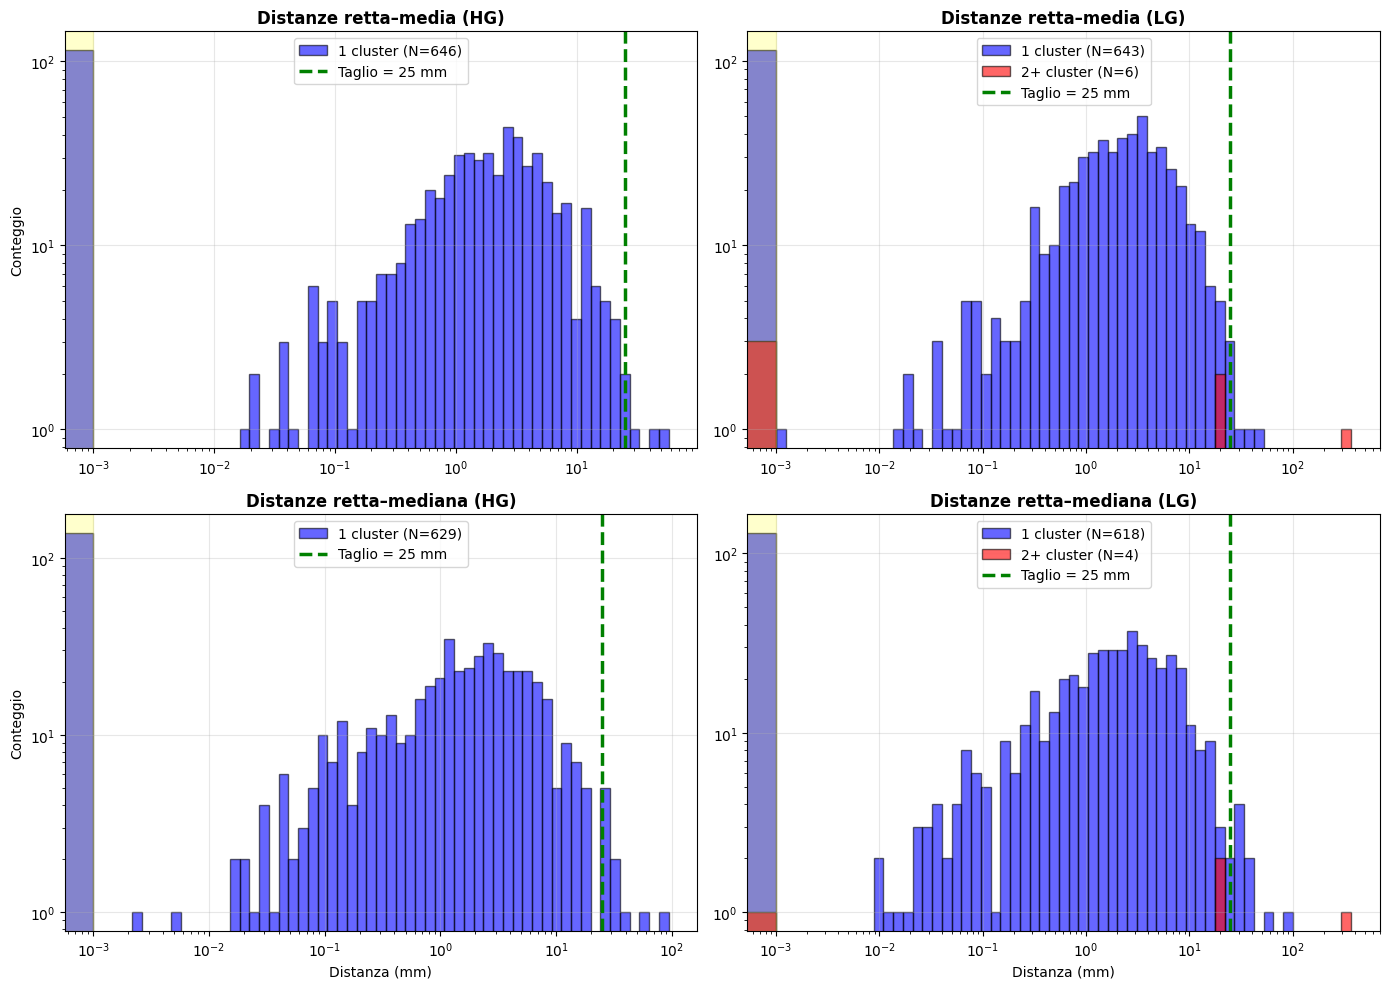


ANALISI DISTRIBUZIONE CLUSTER

HG - Numero di EVENTI:
  1 cluster:  206 (100.0%)
  2+ cluster: 0 (0.0%)
  Totale:     206

LG - Numero di EVENTI:
  1 cluster:  205 (99.5%)
  2+ cluster: 1 (0.5%)
  Totale:     206

EFFETTO DEL TAGLIO A 25 mm

--- HG Mean (weighted) ---

1 cluster:
  Sotto 25 mm: 642 (99.4%)
  Sopra 25 mm: 4 (0.6%)
  Mediana: 1.39 mm
  Media: 2.80 mm
  95° percentile: 10.89 mm

2+ cluster: NESSUN DATO

--- HG Median ---

1 cluster:
  Sotto 25 mm: 620 (98.6%)
  Sopra 25 mm: 9 (1.4%)
  Mediana: 1.06 mm
  Media: 2.80 mm
  95° percentile: 10.55 mm

2+ cluster: NESSUN DATO

--- LG Mean (weighted) ---

1 cluster:
  Sotto 25 mm: 638 (99.2%)
  Sopra 25 mm: 5 (0.8%)
  Mediana: 1.57 mm
  Media: 3.02 mm
  95° percentile: 10.97 mm

2+ cluster:
  Sotto 25 mm: 5 (83.3%)
  Sopra 25 mm: 1 (16.7%)
  Mediana: 9.90 mm
  Media: 62.69 mm
  95° percentile: 256.94 mm

--- LG Median ---

1 cluster:
  Sotto 25 mm: 609 (98.5%)
  Sopra 25 mm: 9 (1.5%)
  Mediana: 1.19 mm
  Media: 3.05 mm
  95° per

In [35]:
# ===================== CONTA CLUSTER PER EVENTO =====================
# Per HG
cluster_count_hg = df_dist_hg.groupby(["event", "mcrun"])["cluster"].nunique().reset_index()
cluster_count_hg.columns = ["event", "mcrun", "n_clusters"]

# Per LG
cluster_count_lg = df_dist_lg.groupby(["event", "mcrun"])["cluster"].nunique().reset_index()
cluster_count_lg.columns = ["event", "mcrun", "n_clusters"]

# Aggiungi info sui cluster al dataframe distanze
df_dist_hg = df_dist_hg.merge(cluster_count_hg, on=["event", "mcrun"], how="left")
df_dist_lg = df_dist_lg.merge(cluster_count_lg, on=["event", "mcrun"], how="left")

# ===================== ESTRAZIONE DISTANZE PER TIPO =====================
# HG - 1 cluster
d_mean_hg_1cl = df_dist_hg[df_dist_hg["n_clusters"] == 1]["d_weight"].values
d_median_hg_1cl = df_dist_hg[df_dist_hg["n_clusters"] == 1]["d_median"].values

# HG - 2+ cluster
d_mean_hg_2cl = df_dist_hg[df_dist_hg["n_clusters"] >= 2]["d_weight"].values
d_median_hg_2cl = df_dist_hg[df_dist_hg["n_clusters"] >= 2]["d_median"].values

# LG - 1 cluster
d_mean_lg_1cl = df_dist_lg[df_dist_lg["n_clusters"] == 1]["d_weight"].values
d_median_lg_1cl = df_dist_lg[df_dist_lg["n_clusters"] == 1]["d_median"].values

# LG - 2+ cluster
d_mean_lg_2cl = df_dist_lg[df_dist_lg["n_clusters"] >= 2]["d_weight"].values
d_median_lg_2cl = df_dist_lg[df_dist_lg["n_clusters"] >= 2]["d_median"].values

# Filtra valori validi
datasets_1cl = [d_mean_hg_1cl, d_median_hg_1cl, d_mean_lg_1cl, d_median_lg_1cl]
datasets_2cl = [d_mean_hg_2cl, d_median_hg_2cl, d_mean_lg_2cl, d_median_lg_2cl]

datasets_1cl = [d[np.isfinite(d) & (d > 0)] for d in datasets_1cl]
datasets_2cl = [d[np.isfinite(d) & (d > 0)] for d in datasets_2cl]

d_mean_hg_1cl, d_median_hg_1cl, d_mean_lg_1cl, d_median_lg_1cl = datasets_1cl
d_mean_hg_2cl, d_median_hg_2cl, d_mean_lg_2cl, d_median_lg_2cl = datasets_2cl

print(f"\nDimensioni array:")
print(f"  HG 1cl:  mean={len(d_mean_hg_1cl)}, median={len(d_median_hg_1cl)}")
print(f"  HG 2+cl: mean={len(d_mean_hg_2cl)}, median={len(d_median_hg_2cl)}")
print(f"  LG 1cl:  mean={len(d_mean_lg_1cl)}, median={len(d_median_lg_1cl)}")
print(f"  LG 2+cl: mean={len(d_mean_lg_2cl)}, median={len(d_median_lg_2cl)}")

# ===================== BINS COMUNI =====================
# Usa solo i dati che esistono
all_mean_hg = np.concatenate([d for d in [d_mean_hg_1cl, d_mean_hg_2cl] if len(d) > 0])
all_median_hg = np.concatenate([d for d in [d_median_hg_1cl, d_median_hg_2cl] if len(d) > 0])
all_mean_lg = np.concatenate([d for d in [d_mean_lg_1cl, d_mean_lg_2cl] if len(d) > 0])
all_median_lg = np.concatenate([d for d in [d_median_lg_1cl, d_median_lg_2cl] if len(d) > 0])

bins_mean_hg = smart_bins(all_mean_hg) if len(all_mean_hg) > 0 else np.linspace(0, 100, 50)
bins_median_hg = smart_bins(all_median_hg) if len(all_median_hg) > 0 else np.linspace(0, 100, 50)
bins_mean_lg = smart_bins(all_mean_lg) if len(all_mean_lg) > 0 else np.linspace(0, 100, 50)
bins_median_lg = smart_bins(all_median_lg) if len(all_median_lg) > 0 else np.linspace(0, 100, 50)

# ===================== DEFINISCI IL TAGLIO =====================
distance_cut = 25  # mm

# ===================== PLOT COMPARATIVO CON CLUSTER =====================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# -------------------- HG Mean --------------------
if len(d_mean_hg_1cl) > 0:
    axes[0,0].hist(d_mean_hg_1cl, bins=bins_mean_hg, edgecolor='black', alpha=0.6, 
                   label=f'1 cluster (N={len(d_mean_hg_1cl)})', color='blue')
if len(d_mean_hg_2cl) > 0:
    axes[0,0].hist(d_mean_hg_2cl, bins=bins_mean_hg, edgecolor='black', alpha=0.6, 
                   label=f'2+ cluster (N={len(d_mean_hg_2cl)})', color='red')
axes[0,0].axvline(distance_cut, color='green', linestyle='--', linewidth=2.5, 
                  label=f'Taglio = {distance_cut} mm')
axes[0,0].set_title("Distanze retta–media (HG)", fontweight='bold')
axes[0,0].set_ylabel("Conteggio")
axes[0,0].legend()

# -------------------- HG Median --------------------
if len(d_median_hg_1cl) > 0:
    axes[1,0].hist(d_median_hg_1cl, bins=bins_median_hg, edgecolor='black', alpha=0.6, 
                   label=f'1 cluster (N={len(d_median_hg_1cl)})', color='blue')
if len(d_median_hg_2cl) > 0:
    axes[1,0].hist(d_median_hg_2cl, bins=bins_median_hg, edgecolor='black', alpha=0.6, 
                   label=f'2+ cluster (N={len(d_median_hg_2cl)})', color='red')
axes[1,0].axvline(distance_cut, color='green', linestyle='--', linewidth=2.5, 
                  label=f'Taglio = {distance_cut} mm')
axes[1,0].set_title("Distanze retta–mediana (HG)", fontweight='bold')
axes[1,0].set_ylabel("Conteggio")
axes[1,0].set_xlabel("Distanza (mm)")
axes[1,0].legend()

# -------------------- LG Mean --------------------
if len(d_mean_lg_1cl) > 0:
    axes[0,1].hist(d_mean_lg_1cl, bins=bins_mean_lg, edgecolor='black', alpha=0.6, 
                   label=f'1 cluster (N={len(d_mean_lg_1cl)})', color='blue')
if len(d_mean_lg_2cl) > 0:
    axes[0,1].hist(d_mean_lg_2cl, bins=bins_mean_lg, edgecolor='black', alpha=0.6, 
                   label=f'2+ cluster (N={len(d_mean_lg_2cl)})', color='red')
axes[0,1].axvline(distance_cut, color='green', linestyle='--', linewidth=2.5, 
                  label=f'Taglio = {distance_cut} mm')
axes[0,1].set_title("Distanze retta–media (LG)", fontweight='bold')
axes[0,1].legend()

# -------------------- LG Median --------------------
if len(d_median_lg_1cl) > 0:
    axes[1,1].hist(d_median_lg_1cl, bins=bins_median_lg, edgecolor='black', alpha=0.6, 
                   label=f'1 cluster (N={len(d_median_lg_1cl)})', color='blue')
if len(d_median_lg_2cl) > 0:
    axes[1,1].hist(d_median_lg_2cl, bins=bins_median_lg, edgecolor='black', alpha=0.6, 
                   label=f'2+ cluster (N={len(d_median_lg_2cl)})', color='red')
axes[1,1].axvline(distance_cut, color='green', linestyle='--', linewidth=2.5, 
                  label=f'Taglio = {distance_cut} mm')
axes[1,1].set_title("Distanze retta–mediana (LG)", fontweight='bold')
axes[1,1].set_xlabel("Distanza (mm)")
axes[1,1].legend()

# Scala log + evidenzia bin ~0
for ax in axes.flat:
    ax.axvspan(0, zero_threshold, alpha=0.2, color='yellow')
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ===================== STATISTICHE DETTAGLIATE =====================
print("\n" + "="*80)
print("ANALISI DISTRIBUZIONE CLUSTER")
print("="*80)

# Conta eventi unici (non righe del dataframe)
n_events_hg_1cl = len(df_dist_hg[df_dist_hg["n_clusters"] == 1].groupby(["event", "mcrun"]))
n_events_hg_2cl = len(df_dist_hg[df_dist_hg["n_clusters"] >= 2].groupby(["event", "mcrun"]))
n_events_lg_1cl = len(df_dist_lg[df_dist_lg["n_clusters"] == 1].groupby(["event", "mcrun"]))
n_events_lg_2cl = len(df_dist_lg[df_dist_lg["n_clusters"] >= 2].groupby(["event", "mcrun"]))

total_events_hg = n_events_hg_1cl + n_events_hg_2cl
total_events_lg = n_events_lg_1cl + n_events_lg_2cl

print(f"\nHG - Numero di EVENTI:")
print(f"  1 cluster:  {n_events_hg_1cl} ({100*n_events_hg_1cl/total_events_hg:.1f}%)")
print(f"  2+ cluster: {n_events_hg_2cl} ({100*n_events_hg_2cl/total_events_hg:.1f}%)")
print(f"  Totale:     {total_events_hg}")

print(f"\nLG - Numero di EVENTI:")
print(f"  1 cluster:  {n_events_lg_1cl} ({100*n_events_lg_1cl/total_events_lg:.1f}%)")
print(f"  2+ cluster: {n_events_lg_2cl} ({100*n_events_lg_2cl/total_events_lg:.1f}%)")
print(f"  Totale:     {total_events_lg}")

print("\n" + "="*80)
print(f"EFFETTO DEL TAGLIO A {distance_cut} mm")
print("="*80)

# Funzione helper per calcolare statistiche (con controllo su array vuoti)
def cut_stats(data, cut_val, label):
    if len(data) == 0:
        print(f"\n{label}: NESSUN DATO")
        return
    
    below = data[data < cut_val]
    above = data[data >= cut_val]
    total = len(data)
    
    print(f"\n{label}:")
    print(f"  Sotto {cut_val} mm: {len(below)} ({100*len(below)/total:.1f}%)")
    print(f"  Sopra {cut_val} mm: {len(above)} ({100*len(above)/total:.1f}%)")
    print(f"  Mediana: {np.median(data):.2f} mm")
    print(f"  Media: {np.mean(data):.2f} mm")
    print(f"  95° percentile: {np.percentile(data, 95):.2f} mm")

# HG
print("\n--- HG Mean (weighted) ---")
cut_stats(d_mean_hg_1cl, distance_cut, "1 cluster")
cut_stats(d_mean_hg_2cl, distance_cut, "2+ cluster")

print("\n--- HG Median ---")
cut_stats(d_median_hg_1cl, distance_cut, "1 cluster")
cut_stats(d_median_hg_2cl, distance_cut, "2+ cluster")

# LG
print("\n--- LG Mean (weighted) ---")
cut_stats(d_mean_lg_1cl, distance_cut, "1 cluster")
cut_stats(d_mean_lg_2cl, distance_cut, "2+ cluster")

print("\n--- LG Median ---")
cut_stats(d_median_lg_1cl, distance_cut, "1 cluster")
cut_stats(d_median_lg_2cl, distance_cut, "2+ cluster")

# ===================== FRAZIONE DI 1-CLUSTER VS 2-CLUSTER PRIMA/DOPO TAGLIO =====================
print("\n" + "="*80)
print(f"COMPOSIZIONE PRIMA E DOPO TAGLIO A {distance_cut} mm")
print("="*80)

def composition_analysis(d_1cl, d_2cl, label):
    if len(d_1cl) == 0 and len(d_2cl) == 0:
        print(f"\n{label}: NESSUN DATO")
        return
    
    # Prima del taglio
    n_1cl_before = len(d_1cl)
    n_2cl_before = len(d_2cl)
    total_before = n_1cl_before + n_2cl_before
    
    if total_before == 0:
        print(f"\n{label}: NESSUN DATO")
        return
    
    # Dopo il taglio
    n_1cl_after = len(d_1cl[d_1cl < distance_cut]) if len(d_1cl) > 0 else 0
    n_2cl_after = len(d_2cl[d_2cl < distance_cut]) if len(d_2cl) > 0 else 0
    total_after = n_1cl_after + n_2cl_after
    
    print(f"\n{label}:")
    print(f"  PRIMA del taglio:")
    print(f"    1 cluster:  {n_1cl_before} ({100*n_1cl_before/total_before:.1f}%)")
    print(f"    2+ cluster: {n_2cl_before} ({100*n_2cl_before/total_before:.1f}%)")
    
    if total_after > 0:
        print(f"  DOPO il taglio:")
        print(f"    1 cluster:  {n_1cl_after} ({100*n_1cl_after/total_after:.1f}%)")
        print(f"    2+ cluster: {n_2cl_after} ({100*n_2cl_after/total_after:.1f}%)")
    
    print(f"  Cambiamento:")
    if n_1cl_before > 0:
        print(f"    1 cluster:  {n_1cl_before - n_1cl_after} rimossi ({100*(n_1cl_before-n_1cl_after)/n_1cl_before:.1f}%)")
    if n_2cl_before > 0:
        print(f"    2+ cluster: {n_2cl_before - n_2cl_after} rimossi ({100*(n_2cl_before-n_2cl_after)/n_2cl_before:.1f}%)")

composition_analysis(d_mean_hg_1cl, d_mean_hg_2cl, "HG Mean (weighted)")
composition_analysis(d_median_hg_1cl, d_median_hg_2cl, "HG Median")
composition_analysis(d_mean_lg_1cl, d_mean_lg_2cl, "LG Mean (weighted)")
composition_analysis(d_median_lg_1cl, d_median_lg_2cl, "LG Median")

print("="*80)

Distribuzione cluster HG:
n_clusters
1    206
Name: count, dtype: int64

Distribuzione cluster LG:
n_clusters
1    205
2      1
Name: count, dtype: int64

Colonne df_dist_hg: ['revent', 'event', 'mcrun', 'cluster', 'tel', 'P_simple', 'P_weight', 'P_median', 'd_simple', 'd_weight', 'd_median', 'n_clusters_x', 'n_clusters_y', 'n_clusters']
Colonne df_dist_lg: ['revent', 'event', 'mcrun', 'cluster', 'tel', 'P_simple', 'P_weight', 'P_median', 'd_simple', 'd_weight', 'd_median', 'n_clusters_x', 'n_clusters_y', 'n_clusters']

Dimensioni array:
  HG 1cl:  mean=646, median=629
  HG 2+cl: mean=0, median=0
  LG 1cl:  mean=643, median=618
  LG 2+cl: mean=6, median=4


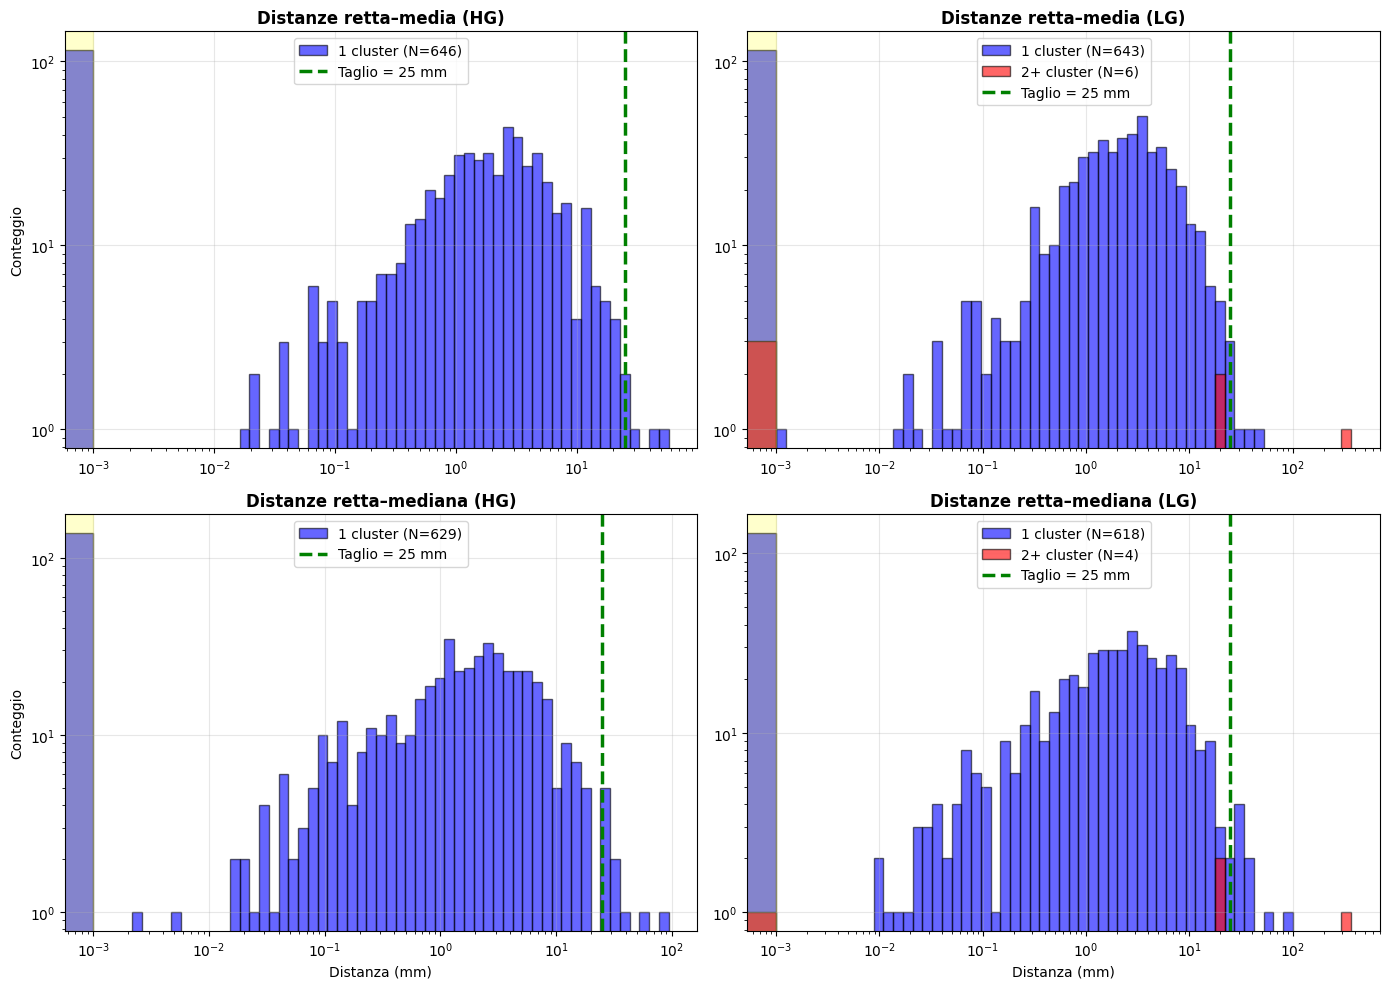


ANALISI DISTRIBUZIONE CLUSTER

HG - Numero di EVENTI:
  1 cluster:  206 (100.0%)
  2+ cluster: 0 (0.0%)
  Totale:     206

LG - Numero di EVENTI:
  1 cluster:  205 (99.5%)
  2+ cluster: 1 (0.5%)
  Totale:     206

EFFETTO DEL TAGLIO A 25 mm

--- HG Mean (weighted) ---

1 cluster:
  Sotto 25 mm: 642 (99.4%)
  Sopra 25 mm: 4 (0.6%)
  Mediana: 1.39 mm
  Media: 2.80 mm
  95° percentile: 10.89 mm

2+ cluster: NESSUN DATO

--- HG Median ---

1 cluster:
  Sotto 25 mm: 620 (98.6%)
  Sopra 25 mm: 9 (1.4%)
  Mediana: 1.06 mm
  Media: 2.80 mm
  95° percentile: 10.55 mm

2+ cluster: NESSUN DATO

--- LG Mean (weighted) ---

1 cluster:
  Sotto 25 mm: 638 (99.2%)
  Sopra 25 mm: 5 (0.8%)
  Mediana: 1.57 mm
  Media: 3.02 mm
  95° percentile: 10.97 mm

2+ cluster:
  Sotto 25 mm: 5 (83.3%)
  Sopra 25 mm: 1 (16.7%)
  Mediana: 9.90 mm
  Media: 62.69 mm
  95° percentile: 256.94 mm

--- LG Median ---

1 cluster:
  Sotto 25 mm: 609 (98.5%)
  Sopra 25 mm: 9 (1.5%)
  Mediana: 1.19 mm
  Media: 3.05 mm
  95° per

In [37]:
# ===================== CONTA CLUSTER PER EVENTO =====================
# Per HG - conta quanti cluster unici per ogni (event, mcrun)
cluster_count_hg = df_dist_hg.groupby(["event", "mcrun"])["cluster"].nunique().reset_index()
cluster_count_hg.columns = ["event", "mcrun", "n_clusters"]

# Per LG
cluster_count_lg = df_dist_lg.groupby(["event", "mcrun"])["cluster"].nunique().reset_index()
cluster_count_lg.columns = ["event", "mcrun", "n_clusters"]

print("Distribuzione cluster HG:")
print(cluster_count_hg["n_clusters"].value_counts().sort_index())
print("\nDistribuzione cluster LG:")
print(cluster_count_lg["n_clusters"].value_counts().sort_index())

# Rimuovi la colonna n_clusters se già esiste (per evitare duplicati)
if "n_clusters" in df_dist_hg.columns:
    df_dist_hg = df_dist_hg.drop(columns=["n_clusters"])
if "n_clusters" in df_dist_lg.columns:
    df_dist_lg = df_dist_lg.drop(columns=["n_clusters"])

# Aggiungi info sui cluster al dataframe distanze
df_dist_hg = df_dist_hg.merge(cluster_count_hg, on=["event", "mcrun"], how="left")
df_dist_lg = df_dist_lg.merge(cluster_count_lg, on=["event", "mcrun"], how="left")

# Verifica che la colonna sia stata aggiunta
print("\nColonne df_dist_hg:", df_dist_hg.columns.tolist())
print("Colonne df_dist_lg:", df_dist_lg.columns.tolist())

# ===================== ESTRAZIONE DISTANZE PER TIPO =====================
# HG - 1 cluster
d_mean_hg_1cl = df_dist_hg[df_dist_hg["n_clusters"] == 1]["d_weight"].values
d_median_hg_1cl = df_dist_hg[df_dist_hg["n_clusters"] == 1]["d_median"].values

# HG - 2+ cluster
d_mean_hg_2cl = df_dist_hg[df_dist_hg["n_clusters"] >= 2]["d_weight"].values
d_median_hg_2cl = df_dist_hg[df_dist_hg["n_clusters"] >= 2]["d_median"].values

# LG - 1 cluster
d_mean_lg_1cl = df_dist_lg[df_dist_lg["n_clusters"] == 1]["d_weight"].values
d_median_lg_1cl = df_dist_lg[df_dist_lg["n_clusters"] == 1]["d_median"].values

# LG - 2+ cluster
d_mean_lg_2cl = df_dist_lg[df_dist_lg["n_clusters"] >= 2]["d_weight"].values
d_median_lg_2cl = df_dist_lg[df_dist_lg["n_clusters"] >= 2]["d_median"].values

# Filtra valori validi
datasets_1cl = [d_mean_hg_1cl, d_median_hg_1cl, d_mean_lg_1cl, d_median_lg_1cl]
datasets_2cl = [d_mean_hg_2cl, d_median_hg_2cl, d_mean_lg_2cl, d_median_lg_2cl]

datasets_1cl = [d[np.isfinite(d) & (d > 0)] for d in datasets_1cl]
datasets_2cl = [d[np.isfinite(d) & (d > 0)] for d in datasets_2cl]

d_mean_hg_1cl, d_median_hg_1cl, d_mean_lg_1cl, d_median_lg_1cl = datasets_1cl
d_mean_hg_2cl, d_median_hg_2cl, d_mean_lg_2cl, d_median_lg_2cl = datasets_2cl

print(f"\nDimensioni array:")
print(f"  HG 1cl:  mean={len(d_mean_hg_1cl)}, median={len(d_median_hg_1cl)}")
print(f"  HG 2+cl: mean={len(d_mean_hg_2cl)}, median={len(d_median_hg_2cl)}")
print(f"  LG 1cl:  mean={len(d_mean_lg_1cl)}, median={len(d_median_lg_1cl)}")
print(f"  LG 2+cl: mean={len(d_mean_lg_2cl)}, median={len(d_median_lg_2cl)}")

# ===================== BINS COMUNI =====================
# Usa solo i dati che esistono
all_mean_hg = np.concatenate([d for d in [d_mean_hg_1cl, d_mean_hg_2cl] if len(d) > 0])
all_median_hg = np.concatenate([d for d in [d_median_hg_1cl, d_median_hg_2cl] if len(d) > 0])
all_mean_lg = np.concatenate([d for d in [d_mean_lg_1cl, d_mean_lg_2cl] if len(d) > 0])
all_median_lg = np.concatenate([d for d in [d_median_lg_1cl, d_median_lg_2cl] if len(d) > 0])

bins_mean_hg = smart_bins(all_mean_hg) if len(all_mean_hg) > 0 else np.linspace(0, 100, 50)
bins_median_hg = smart_bins(all_median_hg) if len(all_median_hg) > 0 else np.linspace(0, 100, 50)
bins_mean_lg = smart_bins(all_mean_lg) if len(all_mean_lg) > 0 else np.linspace(0, 100, 50)
bins_median_lg = smart_bins(all_median_lg) if len(all_median_lg) > 0 else np.linspace(0, 100, 50)

# ===================== DEFINISCI IL TAGLIO =====================
distance_cut = 25  # mm

# ===================== PLOT COMPARATIVO CON CLUSTER =====================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# -------------------- HG Mean --------------------
if len(d_mean_hg_1cl) > 0:
    axes[0,0].hist(d_mean_hg_1cl, bins=bins_mean_hg, edgecolor='black', alpha=0.6, 
                   label=f'1 cluster (N={len(d_mean_hg_1cl)})', color='blue')
if len(d_mean_hg_2cl) > 0:
    axes[0,0].hist(d_mean_hg_2cl, bins=bins_mean_hg, edgecolor='black', alpha=0.6, 
                   label=f'2+ cluster (N={len(d_mean_hg_2cl)})', color='red')
axes[0,0].axvline(distance_cut, color='green', linestyle='--', linewidth=2.5, 
                  label=f'Taglio = {distance_cut} mm')
axes[0,0].set_title("Distanze retta–media (HG)", fontweight='bold')
axes[0,0].set_ylabel("Conteggio")
axes[0,0].legend()

# -------------------- HG Median --------------------
if len(d_median_hg_1cl) > 0:
    axes[1,0].hist(d_median_hg_1cl, bins=bins_median_hg, edgecolor='black', alpha=0.6, 
                   label=f'1 cluster (N={len(d_median_hg_1cl)})', color='blue')
if len(d_median_hg_2cl) > 0:
    axes[1,0].hist(d_median_hg_2cl, bins=bins_median_hg, edgecolor='black', alpha=0.6, 
                   label=f'2+ cluster (N={len(d_median_hg_2cl)})', color='red')
axes[1,0].axvline(distance_cut, color='green', linestyle='--', linewidth=2.5, 
                  label=f'Taglio = {distance_cut} mm')
axes[1,0].set_title("Distanze retta–mediana (HG)", fontweight='bold')
axes[1,0].set_ylabel("Conteggio")
axes[1,0].set_xlabel("Distanza (mm)")
axes[1,0].legend()

# -------------------- LG Mean --------------------
if len(d_mean_lg_1cl) > 0:
    axes[0,1].hist(d_mean_lg_1cl, bins=bins_mean_lg, edgecolor='black', alpha=0.6, 
                   label=f'1 cluster (N={len(d_mean_lg_1cl)})', color='blue')
if len(d_mean_lg_2cl) > 0:
    axes[0,1].hist(d_mean_lg_2cl, bins=bins_mean_lg, edgecolor='black', alpha=0.6, 
                   label=f'2+ cluster (N={len(d_mean_lg_2cl)})', color='red')
axes[0,1].axvline(distance_cut, color='green', linestyle='--', linewidth=2.5, 
                  label=f'Taglio = {distance_cut} mm')
axes[0,1].set_title("Distanze retta–media (LG)", fontweight='bold')
axes[0,1].legend()

# -------------------- LG Median --------------------
if len(d_median_lg_1cl) > 0:
    axes[1,1].hist(d_median_lg_1cl, bins=bins_median_lg, edgecolor='black', alpha=0.6, 
                   label=f'1 cluster (N={len(d_median_lg_1cl)})', color='blue')
if len(d_median_lg_2cl) > 0:
    axes[1,1].hist(d_median_lg_2cl, bins=bins_median_lg, edgecolor='black', alpha=0.6, 
                   label=f'2+ cluster (N={len(d_median_lg_2cl)})', color='red')
axes[1,1].axvline(distance_cut, color='green', linestyle='--', linewidth=2.5, 
                  label=f'Taglio = {distance_cut} mm')
axes[1,1].set_title("Distanze retta–mediana (LG)", fontweight='bold')
axes[1,1].set_xlabel("Distanza (mm)")
axes[1,1].legend()

# Scala log + evidenzia bin ~0
for ax in axes.flat:
    ax.axvspan(0, zero_threshold, alpha=0.2, color='yellow')
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ===================== STATISTICHE DETTAGLIATE =====================
print("\n" + "="*80)
print("ANALISI DISTRIBUZIONE CLUSTER")
print("="*80)

# Conta eventi unici (non righe del dataframe)
n_events_hg_1cl = len(df_dist_hg[df_dist_hg["n_clusters"] == 1].groupby(["event", "mcrun"]))
n_events_hg_2cl = len(df_dist_hg[df_dist_hg["n_clusters"] >= 2].groupby(["event", "mcrun"]))
n_events_lg_1cl = len(df_dist_lg[df_dist_lg["n_clusters"] == 1].groupby(["event", "mcrun"]))
n_events_lg_2cl = len(df_dist_lg[df_dist_lg["n_clusters"] >= 2].groupby(["event", "mcrun"]))

total_events_hg = n_events_hg_1cl + n_events_hg_2cl
total_events_lg = n_events_lg_1cl + n_events_lg_2cl

if total_events_hg > 0:
    print(f"\nHG - Numero di EVENTI:")
    print(f"  1 cluster:  {n_events_hg_1cl} ({100*n_events_hg_1cl/total_events_hg:.1f}%)")
    print(f"  2+ cluster: {n_events_hg_2cl} ({100*n_events_hg_2cl/total_events_hg:.1f}%)")
    print(f"  Totale:     {total_events_hg}")

if total_events_lg > 0:
    print(f"\nLG - Numero di EVENTI:")
    print(f"  1 cluster:  {n_events_lg_1cl} ({100*n_events_lg_1cl/total_events_lg:.1f}%)")
    print(f"  2+ cluster: {n_events_lg_2cl} ({100*n_events_lg_2cl/total_events_lg:.1f}%)")
    print(f"  Totale:     {total_events_lg}")

print("\n" + "="*80)
print(f"EFFETTO DEL TAGLIO A {distance_cut} mm")
print("="*80)

# Funzione helper per calcolare statistiche (con controllo su array vuoti)
def cut_stats(data, cut_val, label):
    if len(data) == 0:
        print(f"\n{label}: NESSUN DATO")
        return
    
    below = data[data < cut_val]
    above = data[data >= cut_val]
    total = len(data)
    
    print(f"\n{label}:")
    print(f"  Sotto {cut_val} mm: {len(below)} ({100*len(below)/total:.1f}%)")
    print(f"  Sopra {cut_val} mm: {len(above)} ({100*len(above)/total:.1f}%)")
    print(f"  Mediana: {np.median(data):.2f} mm")
    print(f"  Media: {np.mean(data):.2f} mm")
    print(f"  95° percentile: {np.percentile(data, 95):.2f} mm")

# HG
print("\n--- HG Mean (weighted) ---")
cut_stats(d_mean_hg_1cl, distance_cut, "1 cluster")
cut_stats(d_mean_hg_2cl, distance_cut, "2+ cluster")

print("\n--- HG Median ---")
cut_stats(d_median_hg_1cl, distance_cut, "1 cluster")
cut_stats(d_median_hg_2cl, distance_cut, "2+ cluster")

# LG
print("\n--- LG Mean (weighted) ---")
cut_stats(d_mean_lg_1cl, distance_cut, "1 cluster")
cut_stats(d_mean_lg_2cl, distance_cut, "2+ cluster")

print("\n--- LG Median ---")
cut_stats(d_median_lg_1cl, distance_cut, "1 cluster")
cut_stats(d_median_lg_2cl, distance_cut, "2+ cluster")

print("="*80)


Distribuzione cluster HG:
n_clusters
1    206
Name: count, dtype: int64

Distribuzione cluster LG:
n_clusters
1    205
2      1
Name: count, dtype: int64

Esempio etichette HG:
     event   mcrun  cluster  n_clusters cl_label_weight cl_label_median
0      100  220290        0           1             1cl             1cl
3      205  220044        0           1             1cl             1cl
5      517  220256        0           1             1cl             1cl
7      616  220296        0           1             1cl             1cl
9     1007  220000        0           1             1cl             1cl
13    1515  220253        0           1             1cl             1cl
17    2217  220030        0           1             1cl             1cl
19    2217  220291        0           1             1cl             1cl
21    2419  220012        0           1             1cl             1cl
27    2419  220026        0           1             1cl             1cl
29    3109  220250        0    

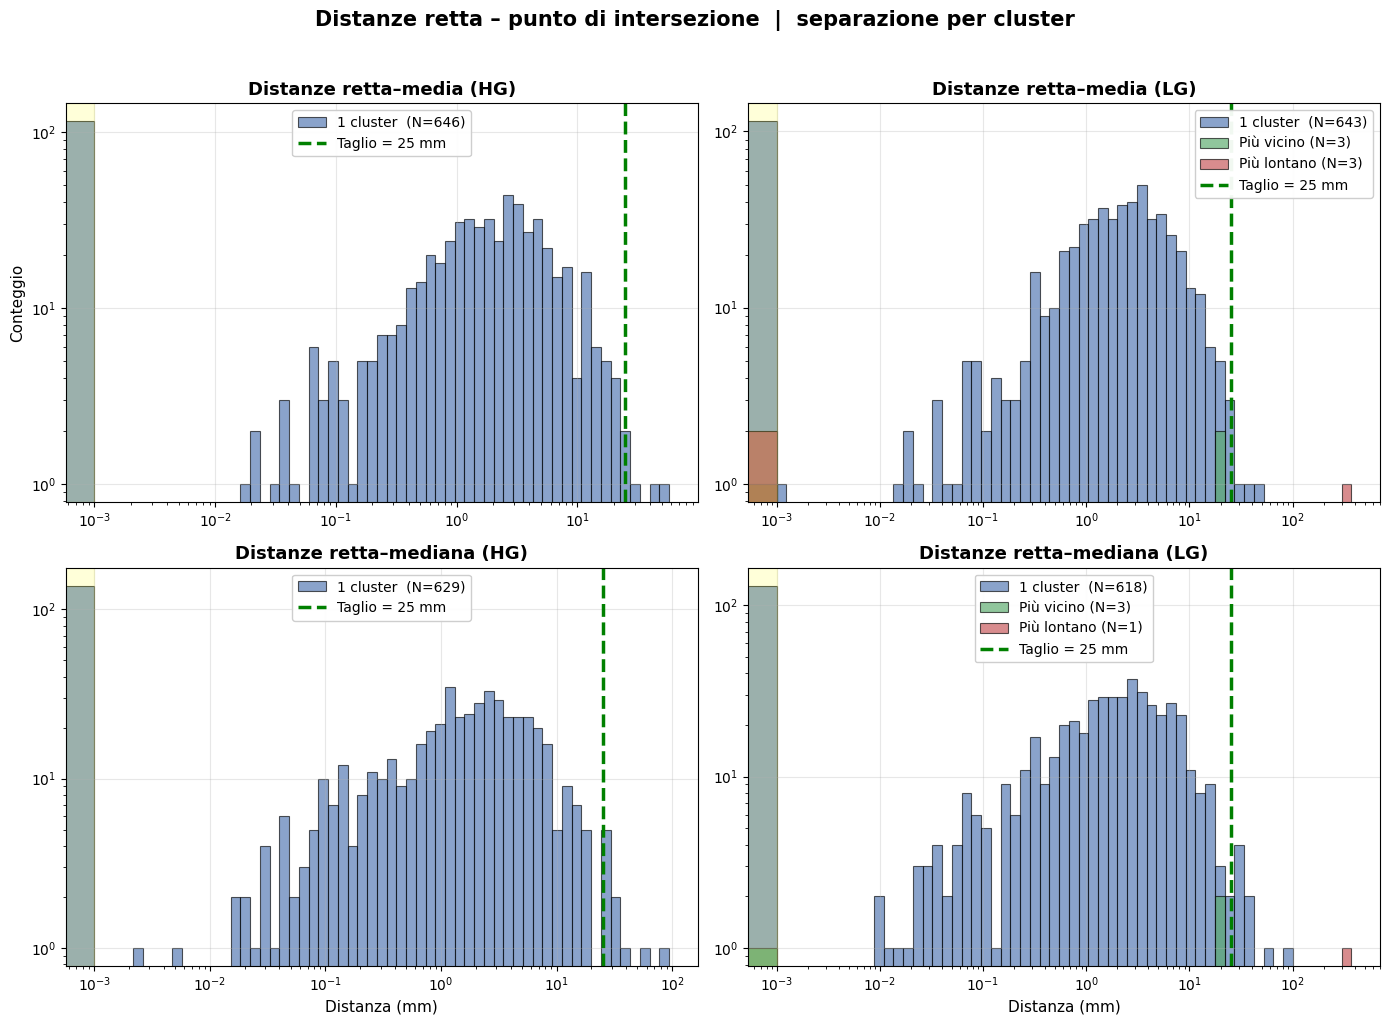


ANALISI DISTRIBUZIONE CLUSTER

HG - Numero di EVENTI:
  1 cluster:  206 (100.0%)
  2+ cluster: 0 (0.0%)
  Totale:     206

LG - Numero di EVENTI:
  1 cluster:  205 (99.5%)
  2+ cluster: 1 (0.5%)
  Totale:     206

EFFETTO DEL TAGLIO A 25 mm

--- HG Mean (weighted) ---

  1 cluster:
    Sotto 25 mm: 642 (99.4%)
    Sopra  25 mm: 4 (0.6%)
    Mediana: 1.39 mm   |   Media: 2.80 mm   |   95°: 10.89 mm

  Più vicino: NESSUN DATO

  Più lontano: NESSUN DATO

--- HG Median ---

  1 cluster:
    Sotto 25 mm: 620 (98.6%)
    Sopra  25 mm: 9 (1.4%)
    Mediana: 1.06 mm   |   Media: 2.80 mm   |   95°: 10.55 mm

  Più vicino: NESSUN DATO

  Più lontano: NESSUN DATO

--- LG Mean (weighted) ---

  1 cluster:
    Sotto 25 mm: 638 (99.2%)
    Sopra  25 mm: 5 (0.8%)
    Mediana: 1.57 mm   |   Media: 3.02 mm   |   95°: 10.97 mm

  Più vicino:
    Sotto 25 mm: 3 (100.0%)
    Sopra  25 mm: 0 (0.0%)
    Mediana: 19.80 mm   |   Media: 13.49 mm   |   95°: 20.58 mm

  Più lontano:
    Sotto 25 mm: 2 (66.7%)


In [38]:
# ===================== CONTA CLUSTER PER EVENTO =====================
cluster_count_hg = df_dist_hg.groupby(["event", "mcrun"])["cluster"].nunique().reset_index()
cluster_count_hg.columns = ["event", "mcrun", "n_clusters"]

cluster_count_lg = df_dist_lg.groupby(["event", "mcrun"])["cluster"].nunique().reset_index()
cluster_count_lg.columns = ["event", "mcrun", "n_clusters"]

print("Distribuzione cluster HG:")
print(cluster_count_hg["n_clusters"].value_counts().sort_index())
print("\nDistribuzione cluster LG:")
print(cluster_count_lg["n_clusters"].value_counts().sort_index())

# Merge n_clusters
for col in ["n_clusters"]:
    if col in df_dist_hg.columns:
        df_dist_hg = df_dist_hg.drop(columns=[col])
    if col in df_dist_lg.columns:
        df_dist_lg = df_dist_lg.drop(columns=[col])

df_dist_hg = df_dist_hg.merge(cluster_count_hg, on=["event", "mcrun"], how="left")
df_dist_lg = df_dist_lg.merge(cluster_count_lg, on=["event", "mcrun"], how="left")

# ===================== FUNZIONE: etichetta cluster vicino/lontano =====================
def label_closest_farthest(df, dist_col):
    """
    Per ogni evento con 2+ cluster, calcola la distanza media del cluster
    rispetto a tutte le rette, poi etichetta come 'closest' o 'farthest'.
    Restituisce una nuova colonna 'cluster_label':
        - '1cl'       → eventi con 1 solo cluster
        - 'closest'   → cluster più vicino alla retta (media distanze minore)
        - 'farthest'  → cluster più lontano dalla retta
    """
    df = df.copy()
    df["cluster_label"] = "1cl"  # default

    # Lavorando solo su eventi con 2+ cluster
    multi = df[df["n_clusters"] >= 2].copy()

    if len(multi) == 0:
        return df

    # Media della distanza per (event, mcrun, cluster) → distanza rappresentativa del cluster
    cl_mean = (
        multi.groupby(["event", "mcrun", "cluster"])[dist_col]
        .mean()
        .reset_index()
        .rename(columns={dist_col: "cl_mean_dist"})
    )

    # Per ogni evento trova il cluster con distanza media minima e massima
    idx_min = cl_mean.groupby(["event", "mcrun"])["cl_mean_dist"].idxmin()
    idx_max = cl_mean.groupby(["event", "mcrun"])["cl_mean_dist"].idxmax()

    closest_clusters = cl_mean.loc[idx_min, ["event", "mcrun", "cluster"]].copy()
    closest_clusters["cluster_label"] = "closest"

    farthest_clusters = cl_mean.loc[idx_max, ["event", "mcrun", "cluster"]].copy()
    farthest_clusters["cluster_label"] = "farthest"

    # Merge le etichette sul df originale (solo per righe 2+ cluster)
    # Prima closest
    df = df.merge(
        closest_clusters.rename(columns={"cluster_label": "_cl_label"}),
        on=["event", "mcrun", "cluster"],
        how="left"
    )
    # Dove match → sovrascrivi
    mask_cl = df["_cl_label"] == "closest"
    df.loc[mask_cl, "cluster_label"] = "closest"
    df.drop(columns=["_cl_label"], inplace=True)

    # Poi farthest
    df = df.merge(
        farthest_clusters.rename(columns={"cluster_label": "_cl_label"}),
        on=["event", "mcrun", "cluster"],
        how="left"
    )
    mask_fa = df["_cl_label"] == "farthest"
    df.loc[mask_fa, "cluster_label"] = "farthest"
    df.drop(columns=["_cl_label"], inplace=True)

    # Casi limite: se min == max (stesso cluster), tutto "closest"
    # già gestito: idxmin e idxmax punteranno allo stesso cluster → label = farthest sovrascrive
    # Forza: se n_clusters == 1 resta "1cl"
    df.loc[df["n_clusters"] == 1, "cluster_label"] = "1cl"

    return df

# Applica per ogni distanza
df_dist_hg = label_closest_farthest(df_dist_hg, "d_weight")
df_dist_hg = df_dist_hg.rename(columns={"cluster_label": "cl_label_weight"})
df_dist_hg = label_closest_farthest(df_dist_hg, "d_median")
df_dist_hg = df_dist_hg.rename(columns={"cluster_label": "cl_label_median"})

df_dist_lg = label_closest_farthest(df_dist_lg, "d_weight")
df_dist_lg = df_dist_lg.rename(columns={"cluster_label": "cl_label_weight"})
df_dist_lg = label_closest_farthest(df_dist_lg, "d_median")
df_dist_lg = df_dist_lg.rename(columns={"cluster_label": "cl_label_median"})

print("\nEsempio etichette HG:")
print(df_dist_hg[["event", "mcrun", "cluster", "n_clusters", "cl_label_weight", "cl_label_median"]].drop_duplicates().to_string())

# ===================== ESTRAZIONE DISTANZE PER TIPO =====================
def extract(df, dist_col, label_col):
    """Estrae array di distanze filtrate per etichetta cluster."""
    out = {}
    for lbl in ["1cl", "closest", "farthest"]:
        vals = df[df[label_col] == lbl][dist_col].values
        vals = vals[np.isfinite(vals) & (vals > 0)]
        out[lbl] = vals
    return out

hg_weight = extract(df_dist_hg, "d_weight", "cl_label_weight")
hg_median = extract(df_dist_hg, "d_median", "cl_label_median")
lg_weight = extract(df_dist_lg, "d_weight", "cl_label_weight")
lg_median = extract(df_dist_lg, "d_median", "cl_label_median")

print(f"\nDimensioni array:")
for tag, data in [("HG weight", hg_weight), ("HG median", hg_median),
                  ("LG weight", lg_weight), ("LG median", lg_median)]:
    print(f"  {tag}: 1cl={len(data['1cl'])}, closest={len(data['closest'])}, farthest={len(data['farthest'])}")

# ===================== BINS COMUNI =====================
def smart_bins_from(data_dict):
    all_vals = np.concatenate([v for v in data_dict.values() if len(v) > 0])
    return smart_bins(all_vals) if len(all_vals) > 0 else np.linspace(0, 100, 50)

bins_hg_w = smart_bins_from(hg_weight)
bins_hg_m = smart_bins_from(hg_median)
bins_lg_w = smart_bins_from(lg_weight)
bins_lg_m = smart_bins_from(lg_median)

# ===================== DEFINISCI IL TAGLIO =====================
distance_cut = 25  # mm

# ===================== COLORI =====================
COL_1CL       = "#4C72B0"   # blu
COL_CLOSEST   = "#55A868"   # verde
COL_FARTHEST  = "#C44E52"   # rosso

# ===================== PLOT =====================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

def plot_panel(ax, data_dict, bins, title, xlabel=None):
    """Plotla un pannello con le 3 categorie."""
    if len(data_dict["1cl"]) > 0:
        ax.hist(data_dict["1cl"], bins=bins, edgecolor='black', linewidth=0.8,
                alpha=0.65, color=COL_1CL,
                label=f'1 cluster  (N={len(data_dict["1cl"])})')
    if len(data_dict["closest"]) > 0:
        ax.hist(data_dict["closest"], bins=bins, edgecolor='black', linewidth=0.8,
                alpha=0.65, color=COL_CLOSEST,
                label=f'Più vicino (N={len(data_dict["closest"])})')
    if len(data_dict["farthest"]) > 0:
        ax.hist(data_dict["farthest"], bins=bins, edgecolor='black', linewidth=0.8,
                alpha=0.65, color=COL_FARTHEST,
                label=f'Più lontano (N={len(data_dict["farthest"])})')

    ax.axvline(distance_cut, color='green', linestyle='--', linewidth=2.5,
               label=f'Taglio = {distance_cut} mm')
    ax.axvspan(0, zero_threshold, alpha=0.15, color='yellow')
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(title, fontweight='bold', fontsize=13)
    ax.legend(fontsize=10, framealpha=0.95)
    ax.grid(True, alpha=0.3)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=11)

# ---- HG ----
plot_panel(axes[0, 0], hg_weight, bins_hg_w, "Distanze retta–media (HG)")
axes[0, 0].set_ylabel("Conteggio", fontsize=11)

plot_panel(axes[1, 0], hg_median, bins_hg_m, "Distanze retta–mediana (HG)",
           xlabel="Distanza (mm)")

# ---- LG ----
plot_panel(axes[0, 1], lg_weight, bins_lg_w, "Distanze retta–media (LG)")
plot_panel(axes[1, 1], lg_median, bins_lg_m, "Distanze retta–mediana (LG)",
           xlabel="Distanza (mm)")

plt.suptitle("Distanze retta – punto di intersezione  |  separazione per cluster",
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ===================== STATISTICHE DETTAGLIATE =====================
print("\n" + "=" * 80)
print("ANALISI DISTRIBUZIONE CLUSTER")
print("=" * 80)

n_events_hg_1cl  = len(df_dist_hg[df_dist_hg["n_clusters"] == 1].groupby(["event", "mcrun"]))
n_events_hg_2cl  = len(df_dist_hg[df_dist_hg["n_clusters"] >= 2].groupby(["event", "mcrun"]))
n_events_lg_1cl  = len(df_dist_lg[df_dist_lg["n_clusters"] == 1].groupby(["event", "mcrun"]))
n_events_lg_2cl  = len(df_dist_lg[df_dist_lg["n_clusters"] >= 2].groupby(["event", "mcrun"]))

for tag, n1, n2 in [("HG", n_events_hg_1cl, n_events_hg_2cl),
                     ("LG", n_events_lg_1cl, n_events_lg_2cl)]:
    tot = n1 + n2
    if tot > 0:
        print(f"\n{tag} - Numero di EVENTI:")
        print(f"  1 cluster:  {n1} ({100*n1/tot:.1f}%)")
        print(f"  2+ cluster: {n2} ({100*n2/tot:.1f}%)")
        print(f"  Totale:     {tot}")

# ===================== STATISTICHE SUL TAGLIO =====================
print("\n" + "=" * 80)
print(f"EFFETTO DEL TAGLIO A {distance_cut} mm")
print("=" * 80)

def cut_stats(data, cut_val, label):
    if len(data) == 0:
        print(f"\n  {label}: NESSUN DATO")
        return
    below = data[data < cut_val]
    above = data[data >= cut_val]
    total = len(data)
    print(f"\n  {label}:")
    print(f"    Sotto {cut_val} mm: {len(below)} ({100*len(below)/total:.1f}%)")
    print(f"    Sopra  {cut_val} mm: {len(above)} ({100*len(above)/total:.1f}%)")
    print(f"    Mediana: {np.median(data):.2f} mm   |   Media: {np.mean(data):.2f} mm   |   95°: {np.percentile(data, 95):.2f} mm")

for tag, w, m in [("HG", hg_weight, hg_median), ("LG", lg_weight, lg_median)]:
    print(f"\n--- {tag} Mean (weighted) ---")
    cut_stats(w["1cl"],       distance_cut, "1 cluster")
    cut_stats(w["closest"],   distance_cut, "Più vicino")
    cut_stats(w["farthest"],  distance_cut, "Più lontano")
    print(f"\n--- {tag} Median ---")
    cut_stats(m["1cl"],       distance_cut, "1 cluster")
    cut_stats(m["closest"],   distance_cut, "Più vicino")
    cut_stats(m["farthest"],  distance_cut, "Più lontano")

print("\n" + "=" * 80)

In [39]:
file_numbers = range(1, 10)  # da 001 a 009
base_path = "astri_{:03d}_43_009_00002_R_200101_001_0201_SEB.lv0"  # pattern del nome file

dfs = []  # lista per accumulare i DataFrame
print("\n")
for i in file_numbers:
    filename = base_path.format(i)
    print(f"{filename}")

    with at.io.fits.AstriFits(filename) as hdul:
        data = hdul[1].data

        # Conversione dei campi
        time_ns = data["TIME_NS"].byteswap().newbyteorder().astype(np.int64)
        time_s  = data["TIME_S"].byteswap().newbyteorder().astype(np.int64)
        event   = data["EVTNUM"].byteswap().newbyteorder().astype(np.int64)
        mcrun   = data["MCRUNNUM"].byteswap().newbyteorder().astype(np.int64)
        ntel    = data["NTRIGTEL"]
        time_abs = time_s * 10**9 + time_ns  # tempo assoluto in ns
        hg, lg, ttp = hdul.get_data('events', ['hi', 'lo', 'ttp'])

        df = pd.DataFrame({
                "TIME_NS": time_ns,
                "TIME_S": time_s,
                "TIME_ABS": time_abs,
                "EVENT": event,
                "MCRUN": mcrun,
                "TEL_ID": i,
                "num_tel": ntel,
                "HG": list(hg),             
                "LG": list(lg),
                "TTP": list(ttp),
            })

        dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)
df_all_sorted = df_all.sort_values(by="TIME_ABS").reset_index(drop=True)
df_all_sorted["shape"] = df_all_sorted["HG"].apply(np.sum).to_numpy()

# ============================================================
# CALIBRAZIONE TEMPORALE: sottra l'offset mediano per telescopio
# ============================================================
# Per ogni telescopio calcoliamo il suo offset mediano rispetto al primo tel
# poi lo sottraiamo direttamente da TIME_ABS

# Offset mediano di ogni tel rispetto al tel più basso
offsets = (
    df_all_sorted
    .groupby(["EVENT", "MCRUN", "TEL_ID"])["TIME_ABS"]
    .first()
    .unstack("TEL_ID")
)
ref_tel = offsets.columns[0]  # telescopio di riferimento
offset_per_tel = (offsets - offsets[ref_tel]).median()  # offset mediano per tel

print("Offset mediano per telescopio (ns):")
print(offset_per_tel)

# Applica direttamente su TIME_ABS
df_all_sorted["TIME_ABS"] = (
    df_all_sorted["TIME_ABS"] 
    - df_all_sorted["TEL_ID"].map(offset_per_tel)
).astype(np.int64)

# ============================================================
# Diagnostica
# ============================================================
dt = df_all_sorted.groupby(["EVENT", "MCRUN"])["TIME_ABS"].apply(lambda x: x.max() - x.min())
n_sotto = (dt < 1000).sum()
n_tot   = len(dt)

print(f"\nEventi con dt < 1000 ns: {n_sotto} / {n_tot} ({100*n_sotto/n_tot:.1f}%)")

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(dt.values, bins=200, color="#4C72B0", edgecolor="black", linewidth=0.8, alpha=0.7)
ax.axvline(1000, color="red", linestyle="--", linewidth=2.5, label="Taglio 1000 ns")
ax.set_xlabel("Δt tra telescopi (ns)", fontsize=13)
ax.set_ylabel("Conteggio", fontsize=13)
ax.set_title("Distribuzione Δt dopo calibrazione", fontweight="bold")
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



astri_001_43_009_00002_R_200101_001_0201_SEB.lv0
astri_002_43_009_00002_R_200101_001_0201_SEB.lv0
astri_003_43_009_00002_R_200101_001_0201_SEB.lv0
astri_004_43_009_00002_R_200101_001_0201_SEB.lv0
astri_005_43_009_00002_R_200101_001_0201_SEB.lv0
astri_006_43_009_00002_R_200101_001_0201_SEB.lv0
astri_007_43_009_00002_R_200101_001_0201_SEB.lv0
astri_008_43_009_00002_R_200101_001_0201_SEB.lv0
astri_009_43_009_00002_R_200101_001_0201_SEB.lv0


ValueError: cannot join with no overlapping index names